# Machine Learning Capstone Project

## Human Activity Recognition

### Classification

The objective of this project is to classify different human physical activities using sensor-based features collected from smartphones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# 1. Dataset Path Verification

The location of the UCI Human Activity Recognition dataset is checked before loading the data.

This ensures that the required dataset folder is available and allows us to inspect its contents.

In [2]:
import os

DATA_PATH = r"C:\Users\kunap\Downloads\UCI HAR Dataset"

print("Dataset folder exists:", os.path.exists(DATA_PATH))
print("Contents:")
print(os.listdir(DATA_PATH))

Dataset folder exists: True
Contents:
['UCI HAR Dataset', '__MACOSX']


# 2. Finding the Dataset and Feature Names

The dataset directory is searched automatically for the `features.txt` file.

The feature names are then loaded into a DataFrame. The UCI HAR dataset contains 561 sensor-based features for each observation.

In [3]:
import os
import pandas as pd

DOWNLOADS = r"C:\Users\kunap\Downloads"

# Find features.txt automatically
features_file = None

for root, dirs, files in os.walk(DOWNLOADS):
    if "features.txt" in files:
        features_file = os.path.join(root, "features.txt")
        break

if features_file is None:
    print("❌ features.txt was not found.")
else:
    DATA_PATH = os.path.dirname(features_file)

    print("✅ Dataset found!")
    print("DATA_PATH:", DATA_PATH)

    print("\nFiles found:")
    print(os.listdir(DATA_PATH))

    # Load feature names
    features = pd.read_csv(
        features_file,
        sep=r"\s+",
        header=None,
        names=["index", "feature"]
    )

    print("\nNumber of features:", len(features))
    display(features.head(10))

✅ Dataset found!
DATA_PATH: C:\Users\kunap\Downloads\UCI HAR Dataset\UCI HAR Dataset

Files found:
['.DS_Store', 'activity_labels.txt', 'features.txt', 'features_info.txt', 'README.txt', 'test', 'train']

Number of features: 561


,index,feature
0,1,tBodyAcc-mean()-X
1,2,tBodyAcc-mean()-Y
2,3,tBodyAcc-mean()-Z
3,4,tBodyAcc-std()-X
4,5,tBodyAcc-std()-Y
5,6,tBodyAcc-std()-Z
6,7,tBodyAcc-mad()-X
7,8,tBodyAcc-mad()-Y
8,9,tBodyAcc-mad()-Z
9,10,tBodyAcc-max()-X


# 3. Activity Labels

The activity label file is loaded to map numerical activity IDs to their corresponding human activity names.

The dataset contains six activities: walking, walking upstairs, walking downstairs, sitting, standing, and laying.

In [4]:
activity_labels = pd.read_csv(
    os.path.join(DATA_PATH, "activity_labels.txt"),
    sep=r"\s+",
    header=None,
    names=["activity_id", "activity"]
)

activity_labels

,activity_id,activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


# 4. Loading Training Data

The training feature matrix and corresponding activity labels are loaded from the training directory.

The training dataset contains 7352 observations and 561 features.

In [5]:
X_train_original = pd.read_csv(
    os.path.join(DATA_PATH, "train", "X_train.txt"),
    sep=r"\s+",
    header=None
)

y_train_original = pd.read_csv(
    os.path.join(DATA_PATH, "train", "y_train.txt"),
    sep=r"\s+",
    header=None,
    names=["activity_id"]
)

print("X_train shape:", X_train_original.shape)
print("y_train shape:", y_train_original.shape)

X_train shape: (7352, 561)
y_train shape: (7352, 1)


# 5. Loading Testing Data

The testing feature matrix and corresponding activity labels are loaded from the testing directory.

The testing dataset contains 2947 observations and 561 features.

In [6]:
X_test_original = pd.read_csv(
    os.path.join(DATA_PATH, "test", "X_test.txt"),
    sep=r"\s+",
    header=None
)

y_test_original = pd.read_csv(
    os.path.join(DATA_PATH, "test", "y_test.txt"),
    sep=r"\s+",
    header=None,
    names=["activity_id"]
)

print("X_test shape:", X_test_original.shape)
print("y_test shape:", y_test_original.shape)

X_test shape: (2947, 561)
y_test shape: (2947, 1)


# 6. Assigning Feature Names

The 561 feature names obtained from `features.txt` are assigned to both the training and testing feature matrices.

This makes the dataset easier to understand and analyse.

In [7]:
feature_names = features["feature"].tolist()

X_train_original.columns = feature_names
X_test_original.columns = feature_names

print("Feature names assigned successfully.")
print(X_train_original.shape)
print(X_test_original.shape)

Feature names assigned successfully.
(7352, 561)
(2947, 561)


# 7. Combining Training and Testing Data

The training and testing feature matrices are combined into a single feature dataset.

The corresponding activity labels are also combined so that the complete dataset can be analysed together.

In [8]:
X = pd.concat(
    [X_train_original, X_test_original],
    ignore_index=True
)

y = pd.concat(
    [y_train_original, y_test_original],
    ignore_index=True
)["activity_id"]

print("Combined feature shape:", X.shape)
print("Combined target shape:", y.shape)

Combined feature shape: (10299, 561)
Combined target shape: (10299,)


# 8. Activity Distribution Analysis

The numerical activity IDs are converted into meaningful activity names.

The class distribution is examined to understand how many observations belong to each human activity.

In [9]:
activity_map = dict(
    zip(
        activity_labels["activity_id"],
        activity_labels["activity"]
    )
)

y_named = y.map(activity_map)

print(y_named.value_counts())

activity_id
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


### Observation

The dataset contains six human activity classes: walking, walking upstairs, walking downstairs, sitting, standing, and laying. The class counts are reasonably distributed, although the number of samples differs between activities.

# 9. Dataset Overview

The complete dataset is inspected to determine the number of observations, number of features, data types, and sample records.

The dataset contains 10299 observations and 561 numerical features.

In [10]:
print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nData types:")
print(X.dtypes.value_counts())

print("\nFirst 5 rows:")
display(X.head())

Number of rows: 10299
Number of features: 561

Data types:
float64    561
Name: count, dtype: int64

First 5 rows:


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


# 10. Missing Value Analysis

The dataset is checked for missing values.

This step ensures that incomplete feature values do not cause problems during model training.

In [11]:
missing_values = X.isnull().sum()

print("Total missing values:", missing_values.sum())

if missing_values.sum() == 0:
    print("No missing values found.")

Total missing values: 0
No missing values found.


# 11. Duplicate Analysis

Duplicate feature rows are checked to identify repeated observations in the dataset.

This helps verify the uniqueness of the observations used for classification.

In [12]:
duplicate_count = X.duplicated().sum()
print("Number of duplicate feature rows:", duplicate_count)

Number of duplicate feature rows: 0


## Outlier Detection and Treatment

Outliers were checked using the Interquartile Range (IQR) method. Since this dataset contains many sensor-derived numerical features, extreme values were identified without automatically removing observations, as they may represent genuine variations in human movement. During preprocessing, extreme feature values are capped using limits calculated from the training data to reduce the influence of unusually large values while preserving the observations.

In [13]:
# Outlier detection using IQR
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = ((X < lower_bound) | (X > upper_bound)).sum()

outlier_summary = pd.DataFrame({
    "Outlier Count": outlier_counts,
    "Outlier Percentage": (outlier_counts / len(X)) * 100
})

outlier_summary.sort_values(
    by="Outlier Count",
    ascending=False
).head(20)

,Outlier Count,Outlier Percentage
tBodyAccJerk-mean()-X,3871,37.586173
tBodyGyro-mean()-X,3290,31.944849
tBodyGyroJerk-mean()-X,3148,30.566074
tBodyAccJerk-mean()-Y,3064,29.750461
tBodyGyroJerk-mean()-Y,3048,29.595106
tBodyAccJerk-mean()-Z,2777,26.963783
tBodyGyroJerk-mean()-Z,2736,26.565686
tBodyGyro-mean()-Y,2466,23.944072
tBodyAcc-mean()-X,2437,23.662492
tBodyGyro-mean()-Z,2238,21.730265


# 14. Distribution of Representative HAR Features

A small set of representative features is selected from the 561 available features.

Histograms are plotted to observe the distribution of these sensor-based features.

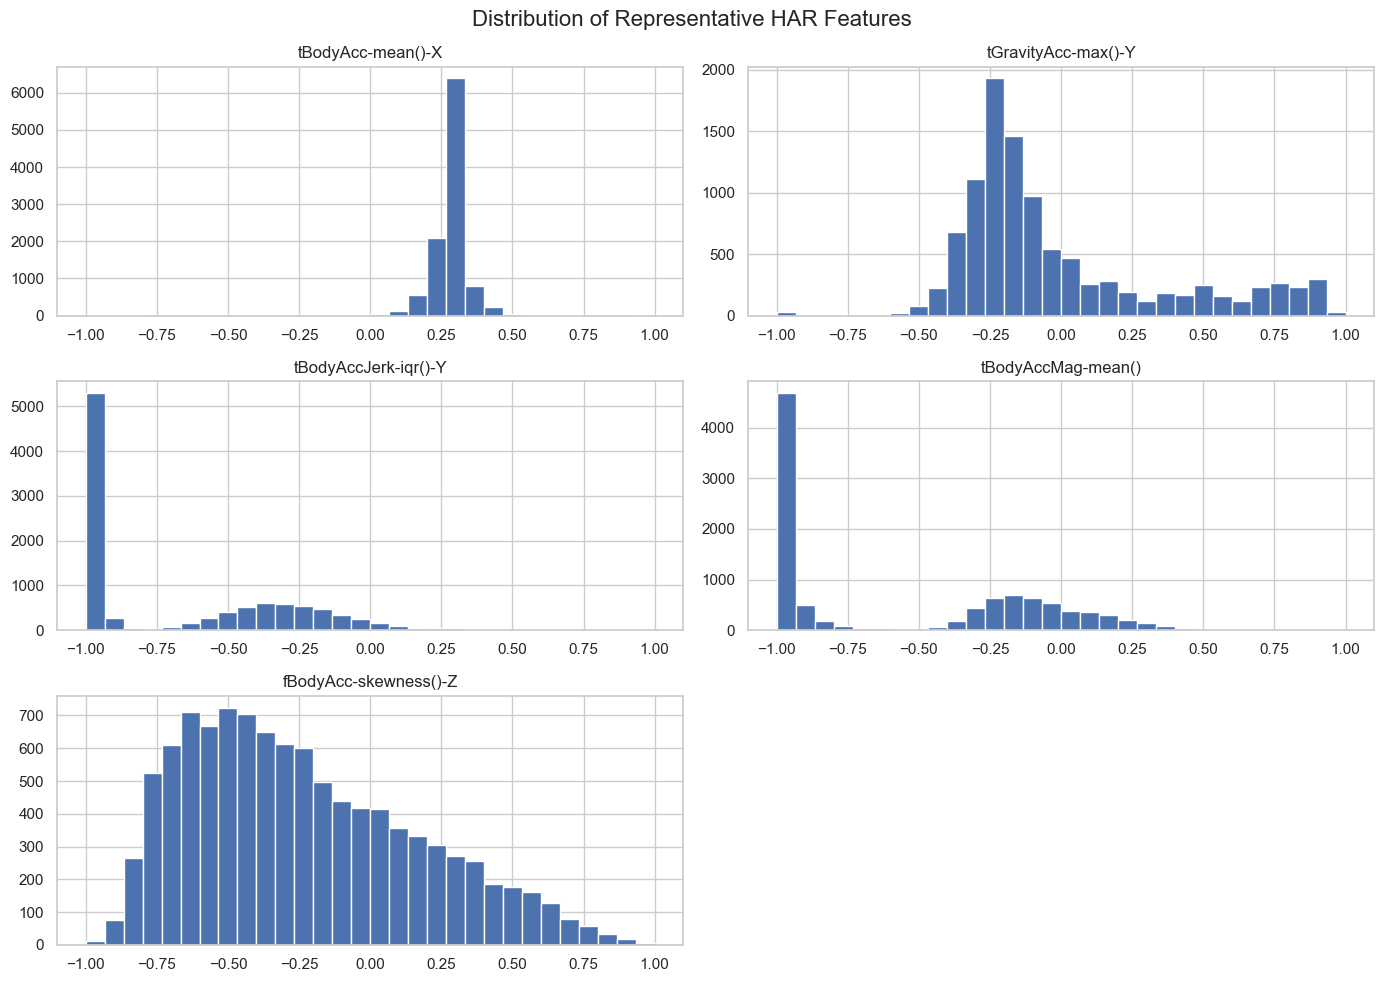

In [14]:
selected_features = [
    feature_names[0],
    feature_names[50],
    feature_names[100],
    feature_names[200],
    feature_names[300]
]

X[selected_features].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle(
    "Distribution of Representative HAR Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Observation

The representative sensor features show different distributions and ranges. Some features are concentrated around particular values, while others have wider variation. This demonstrates the diversity of the sensor measurements used for activity classification.

## Distribution of All Features

The dataset contains a large number of numerical sensor features. To examine the distribution of every feature without creating an excessively long notebook, the features are visualized in batches. Each batch contains 25 feature distributions.

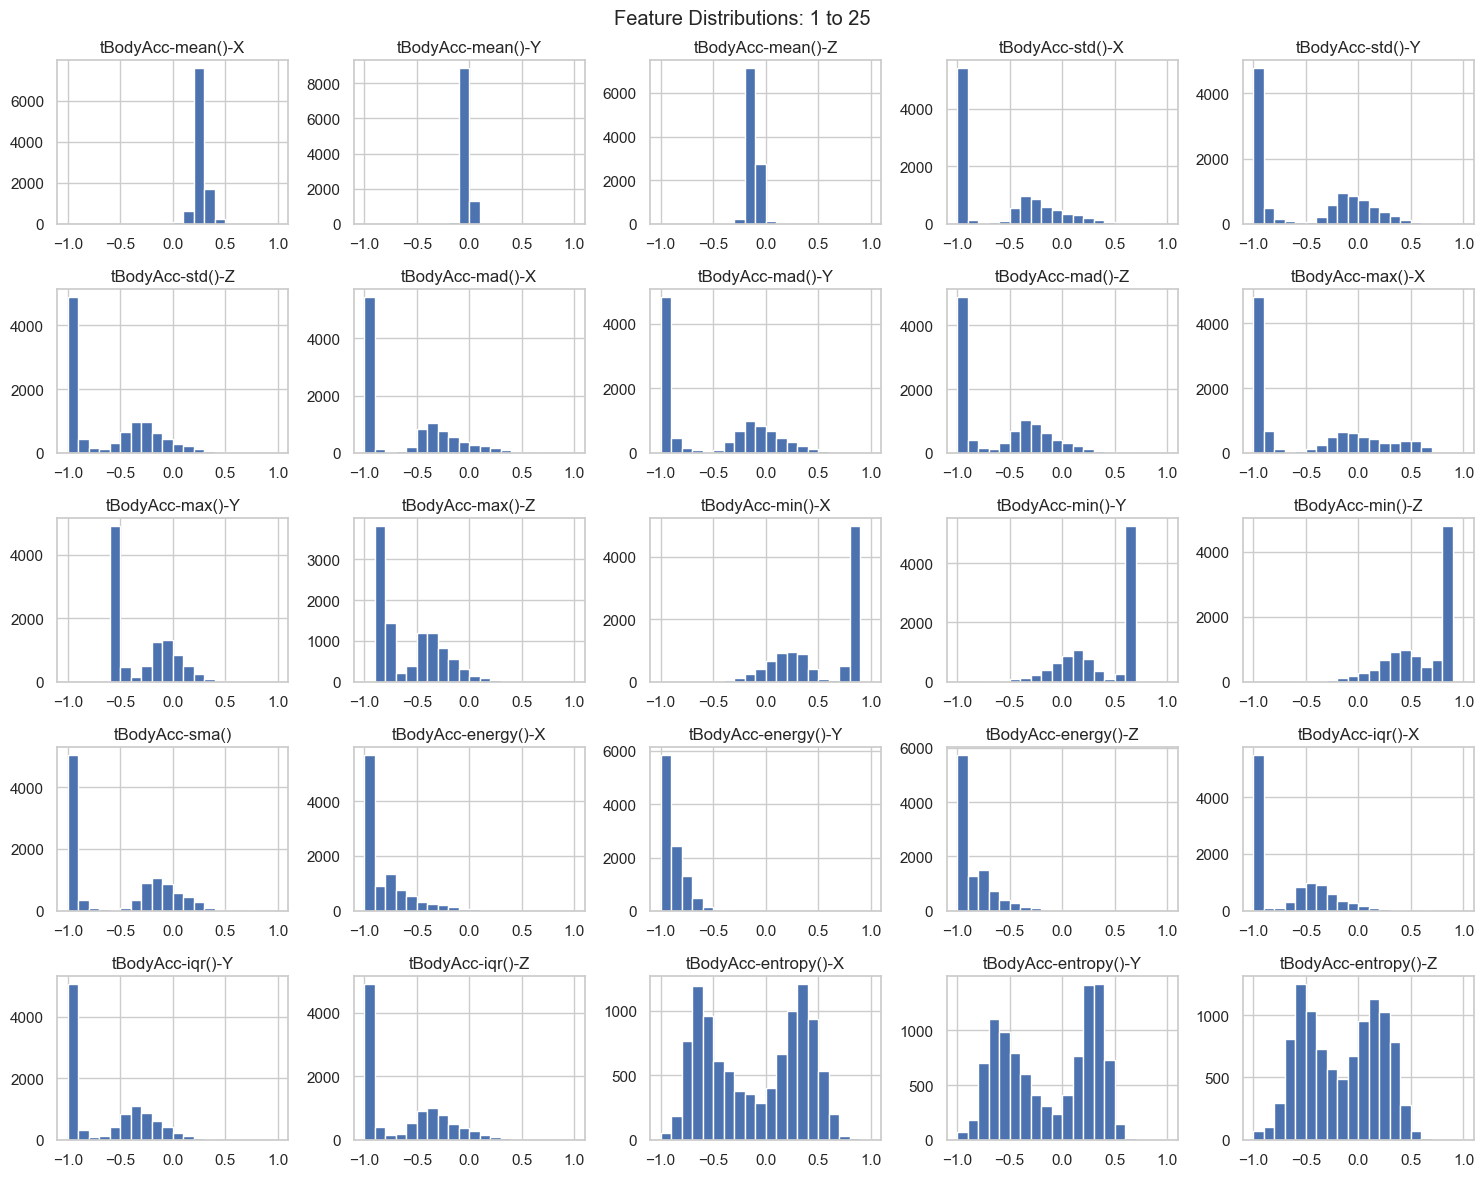

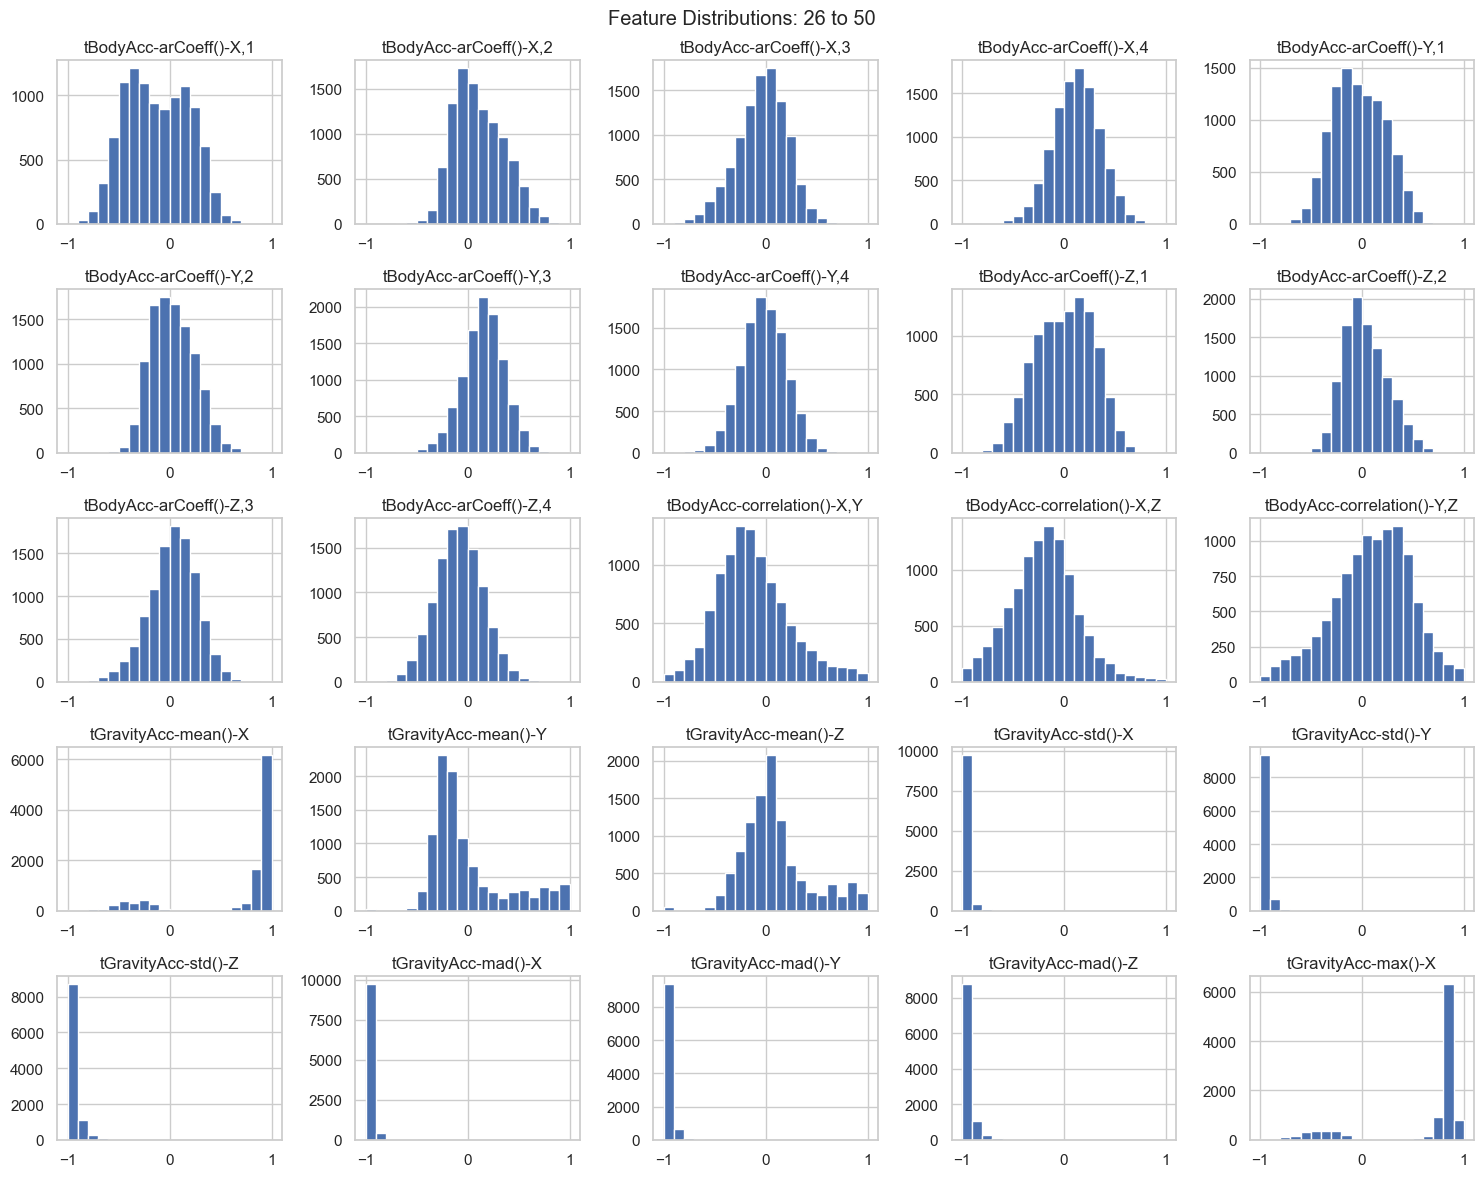

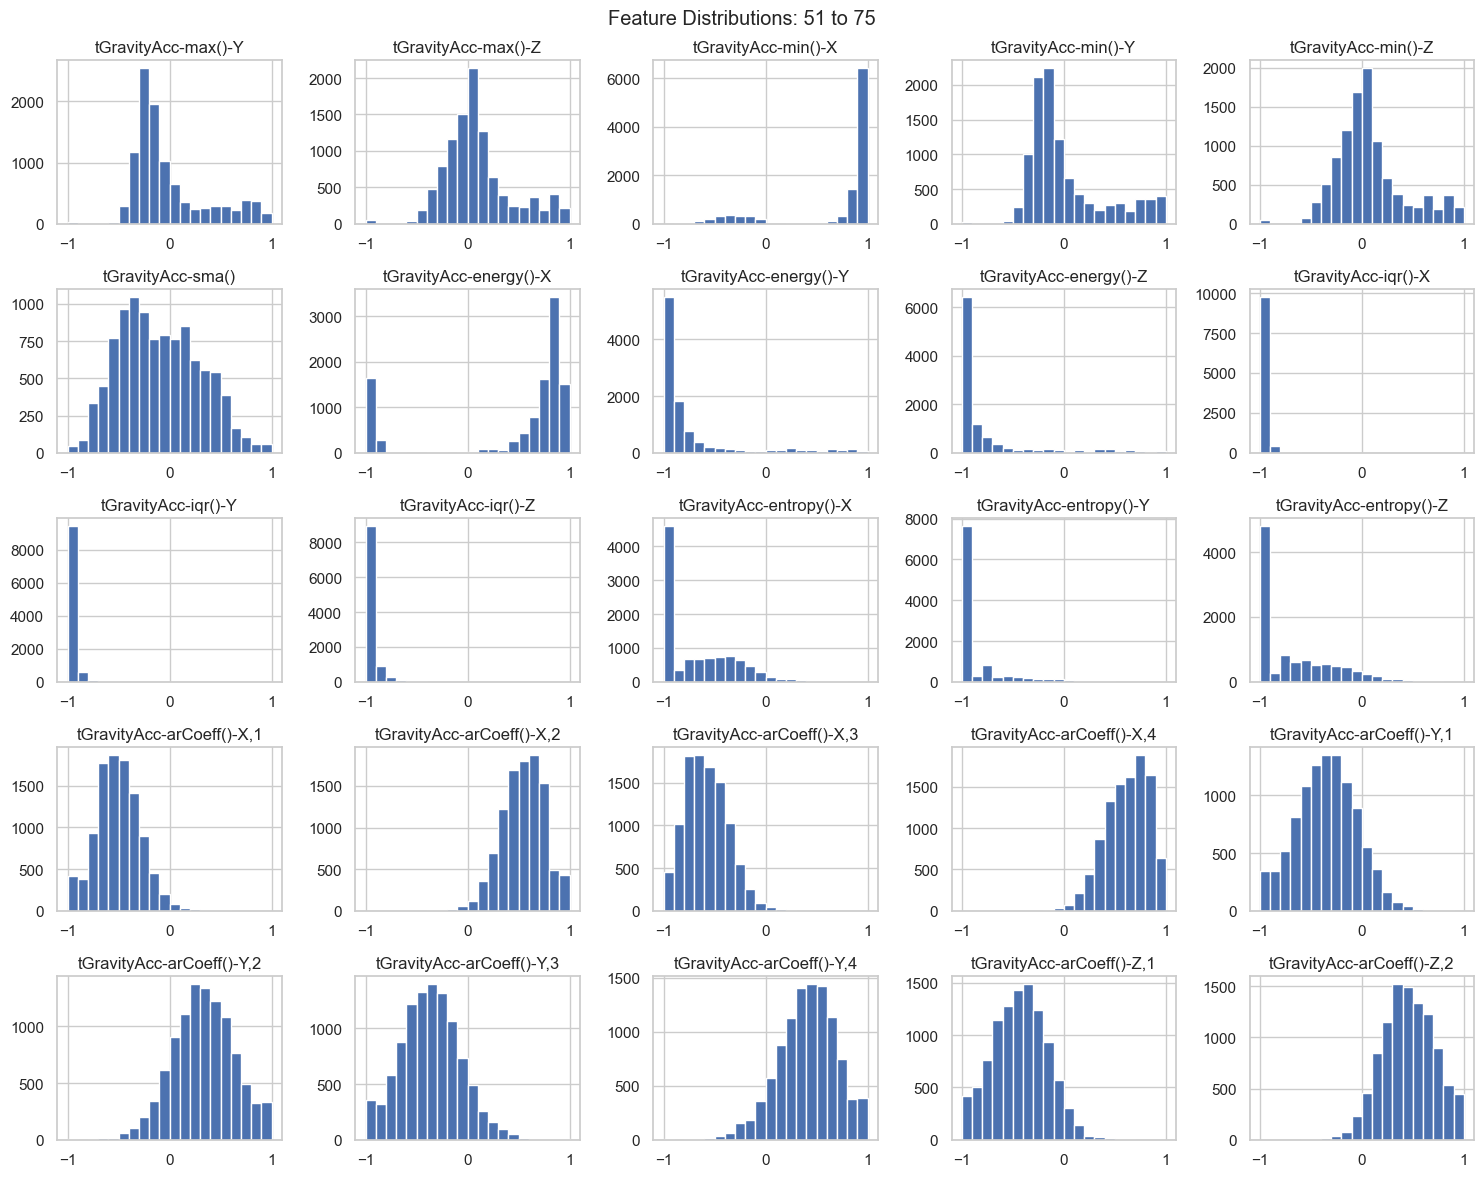

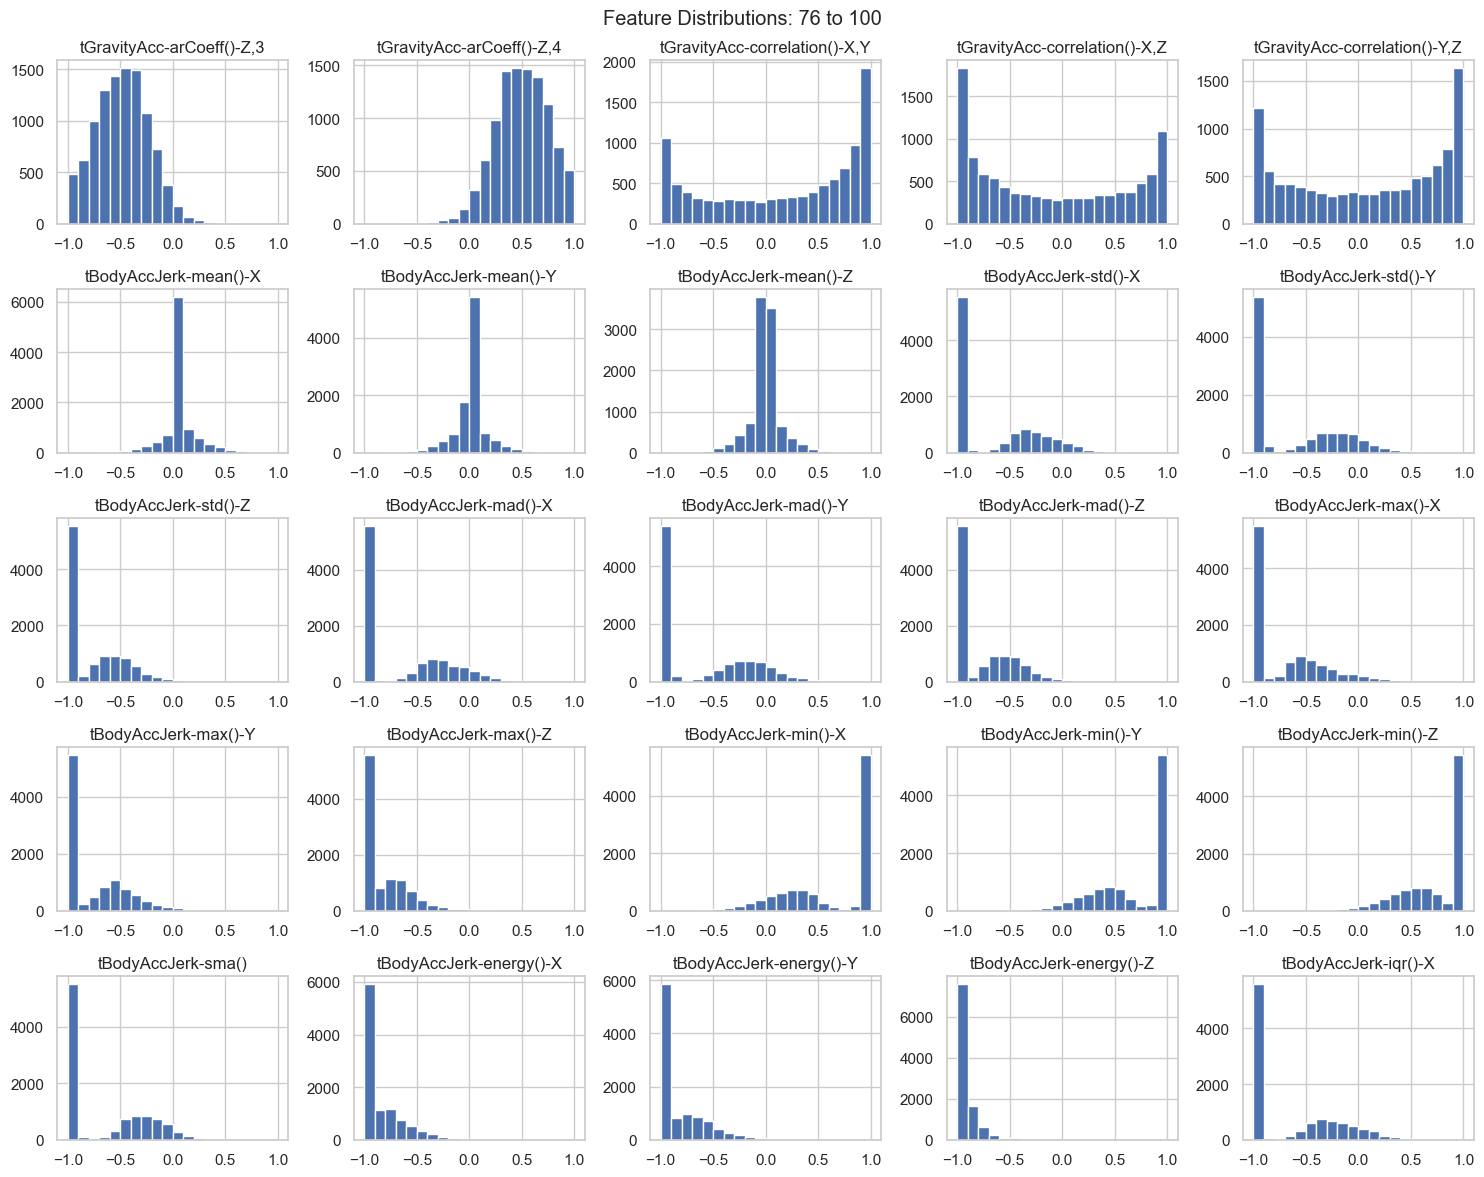

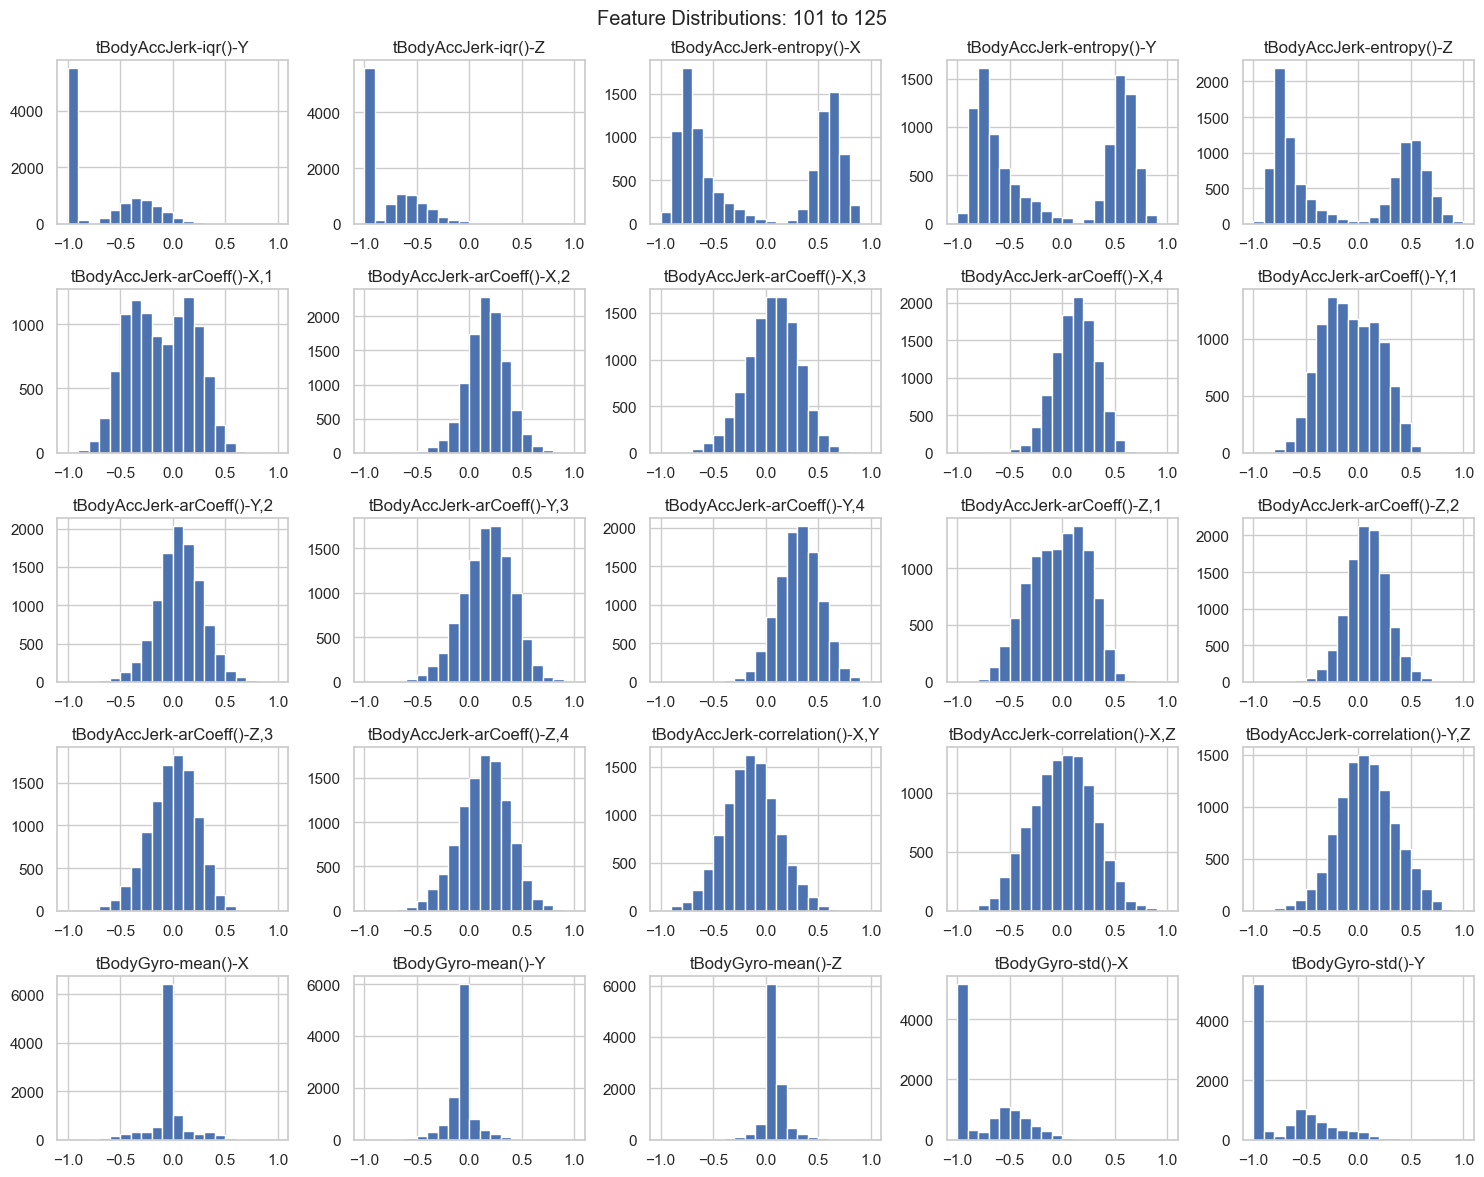

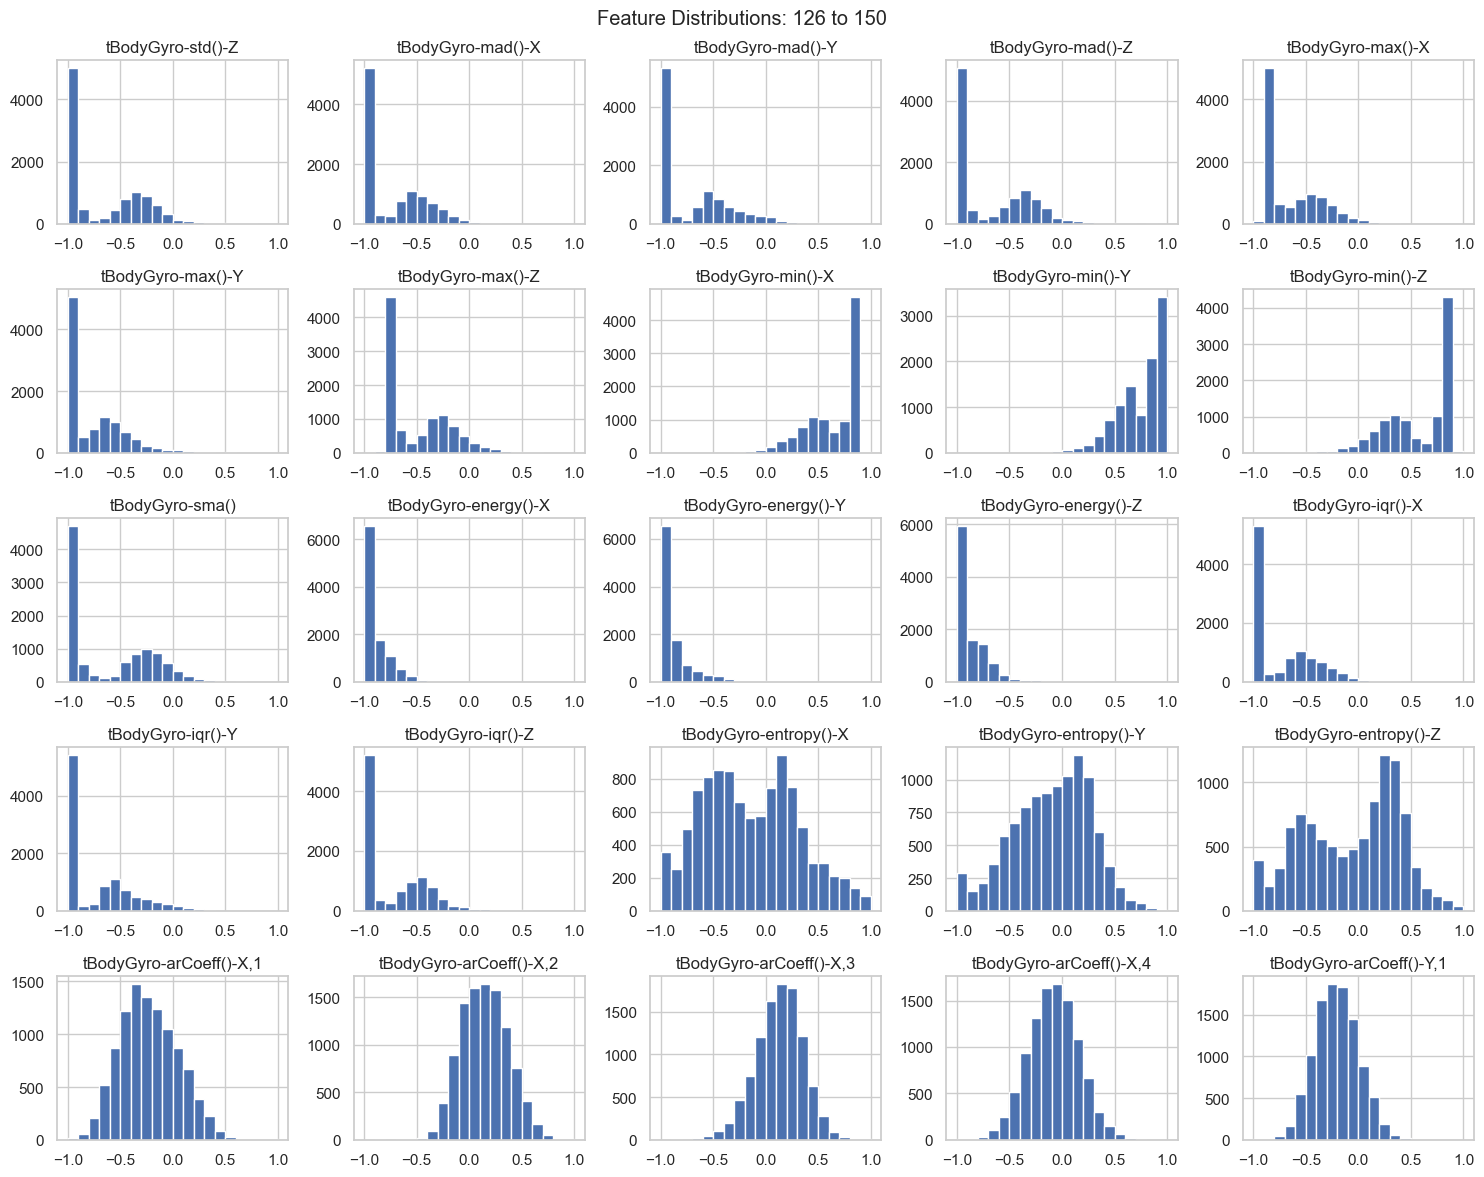

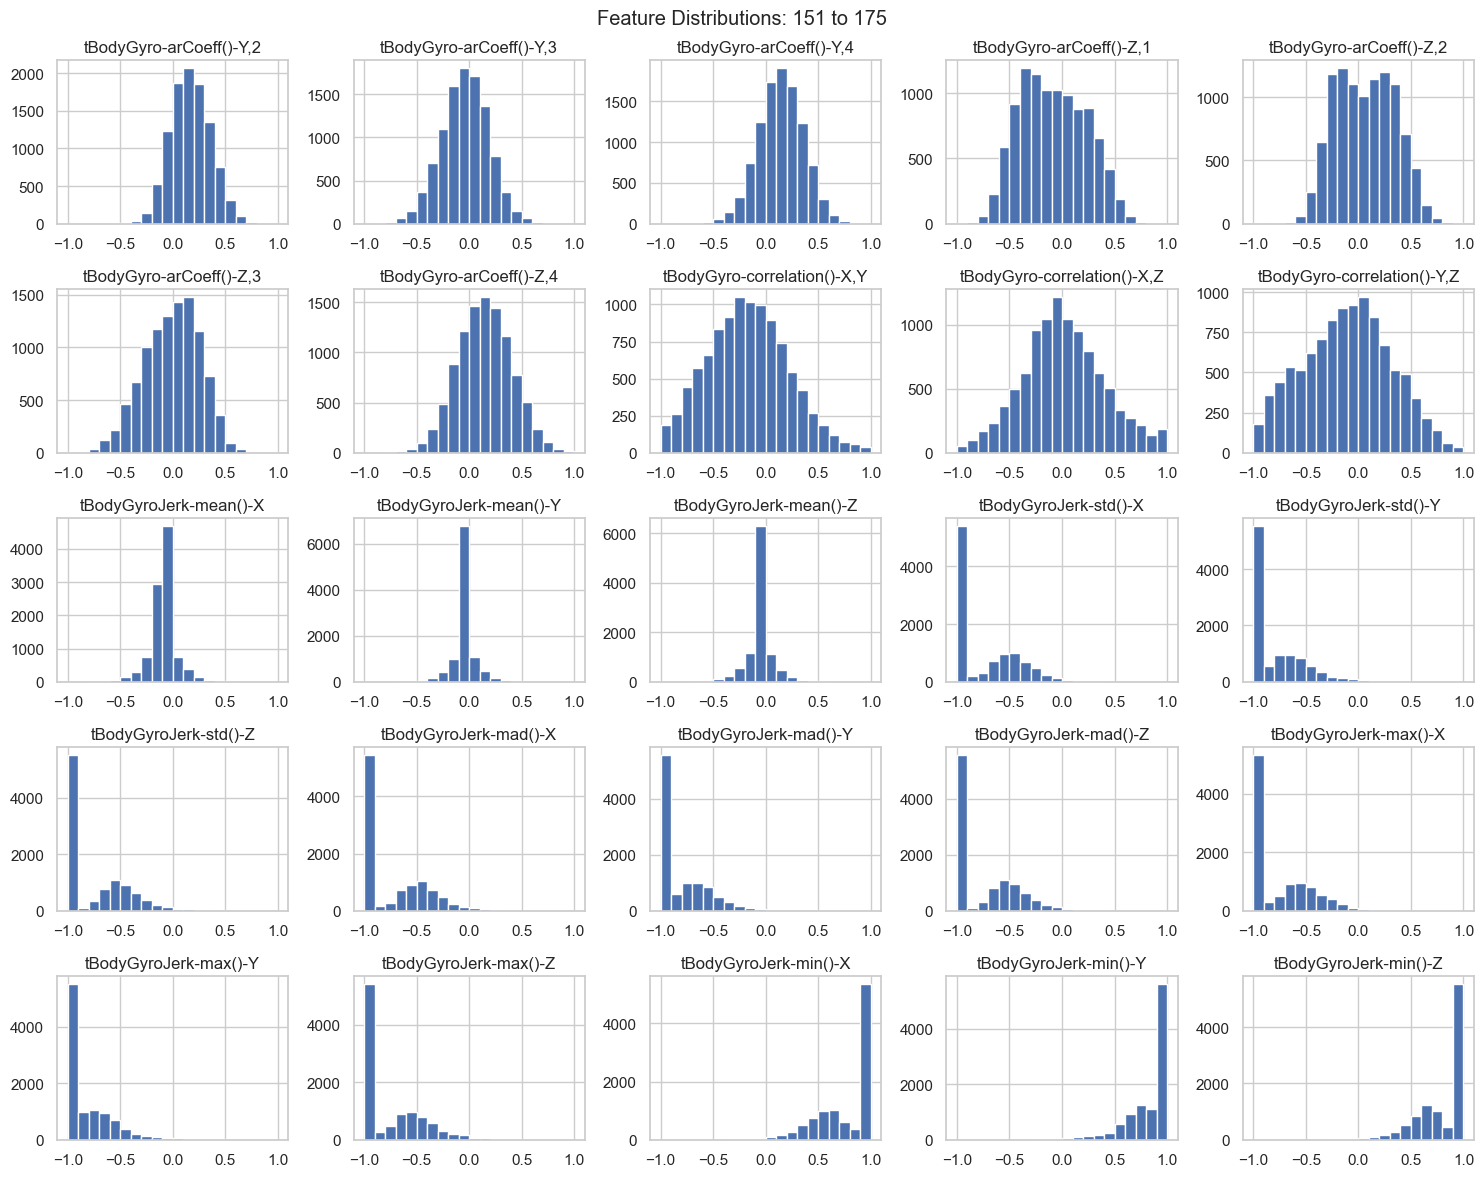

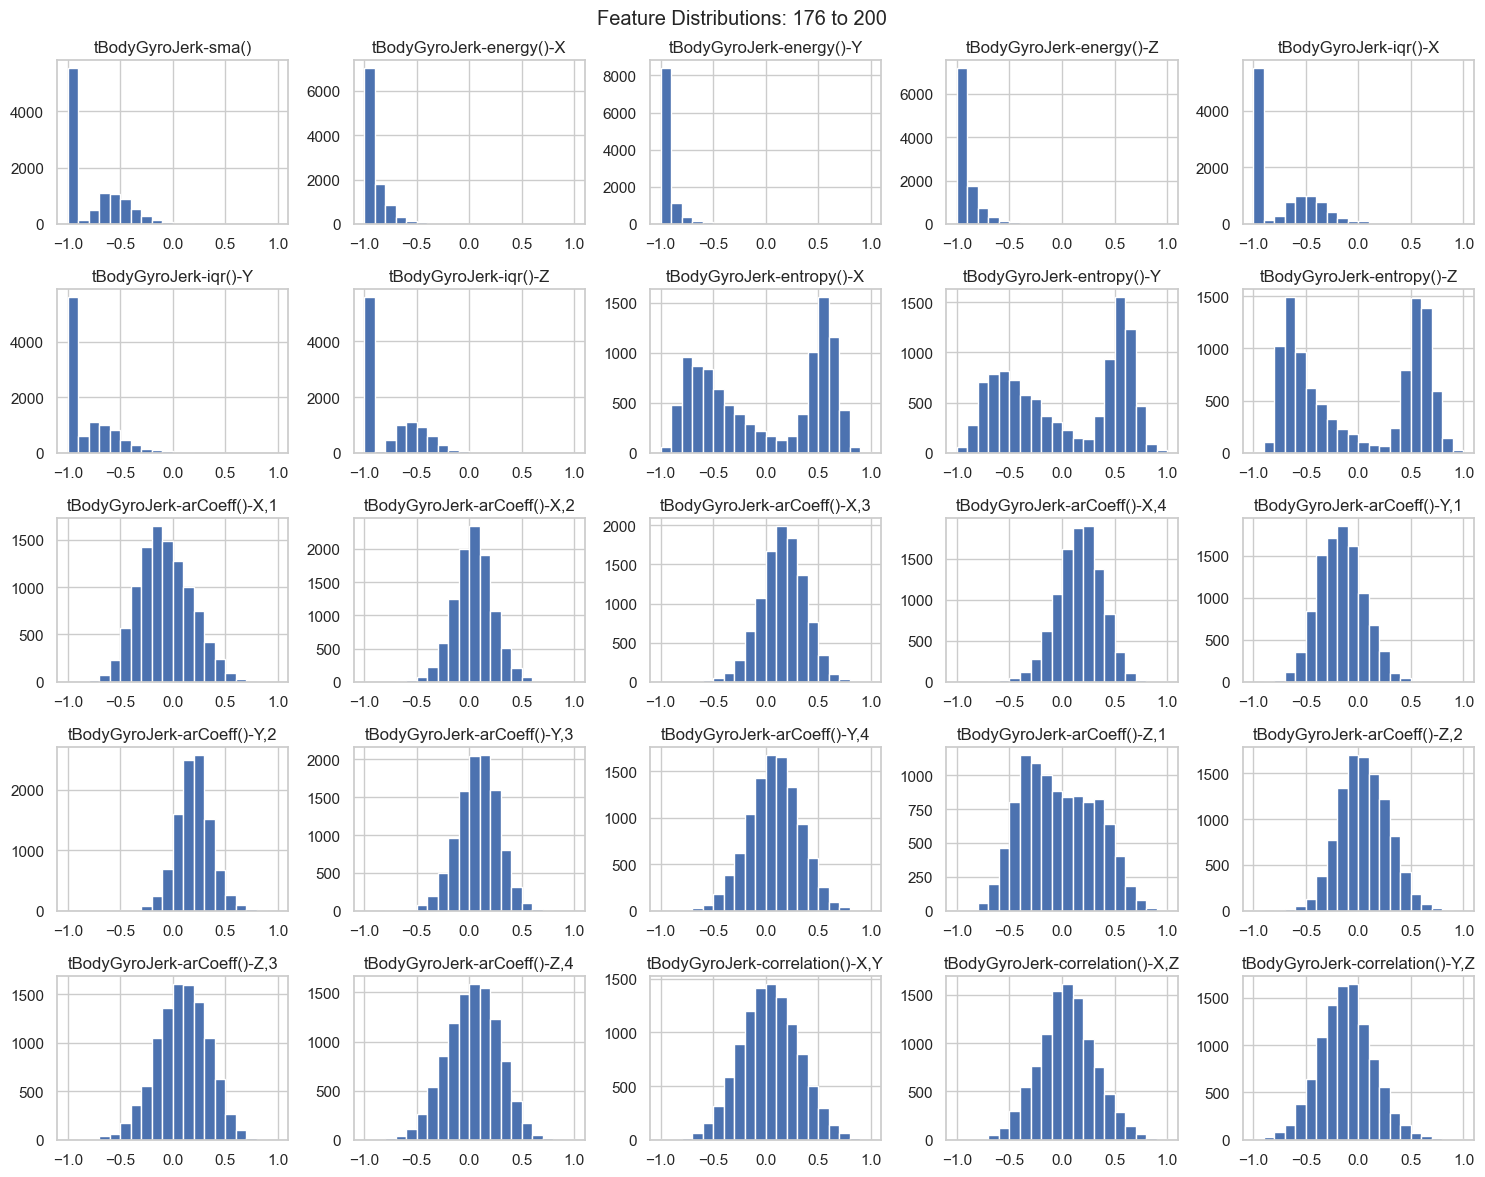

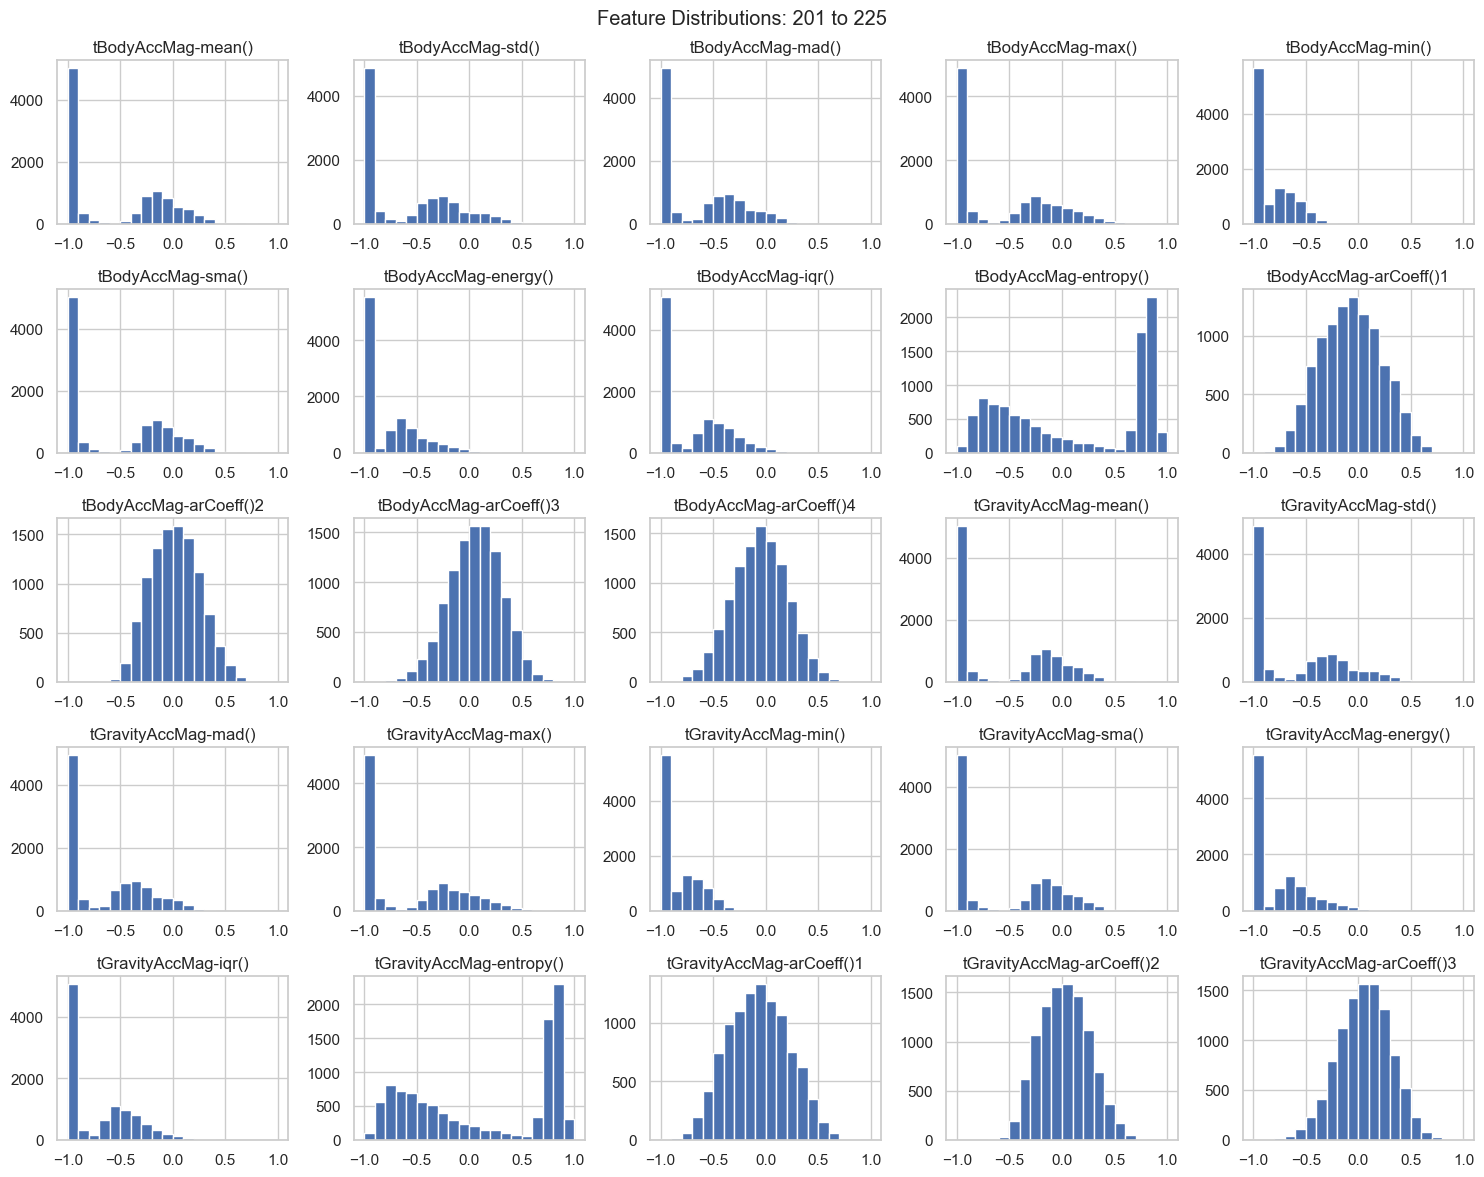

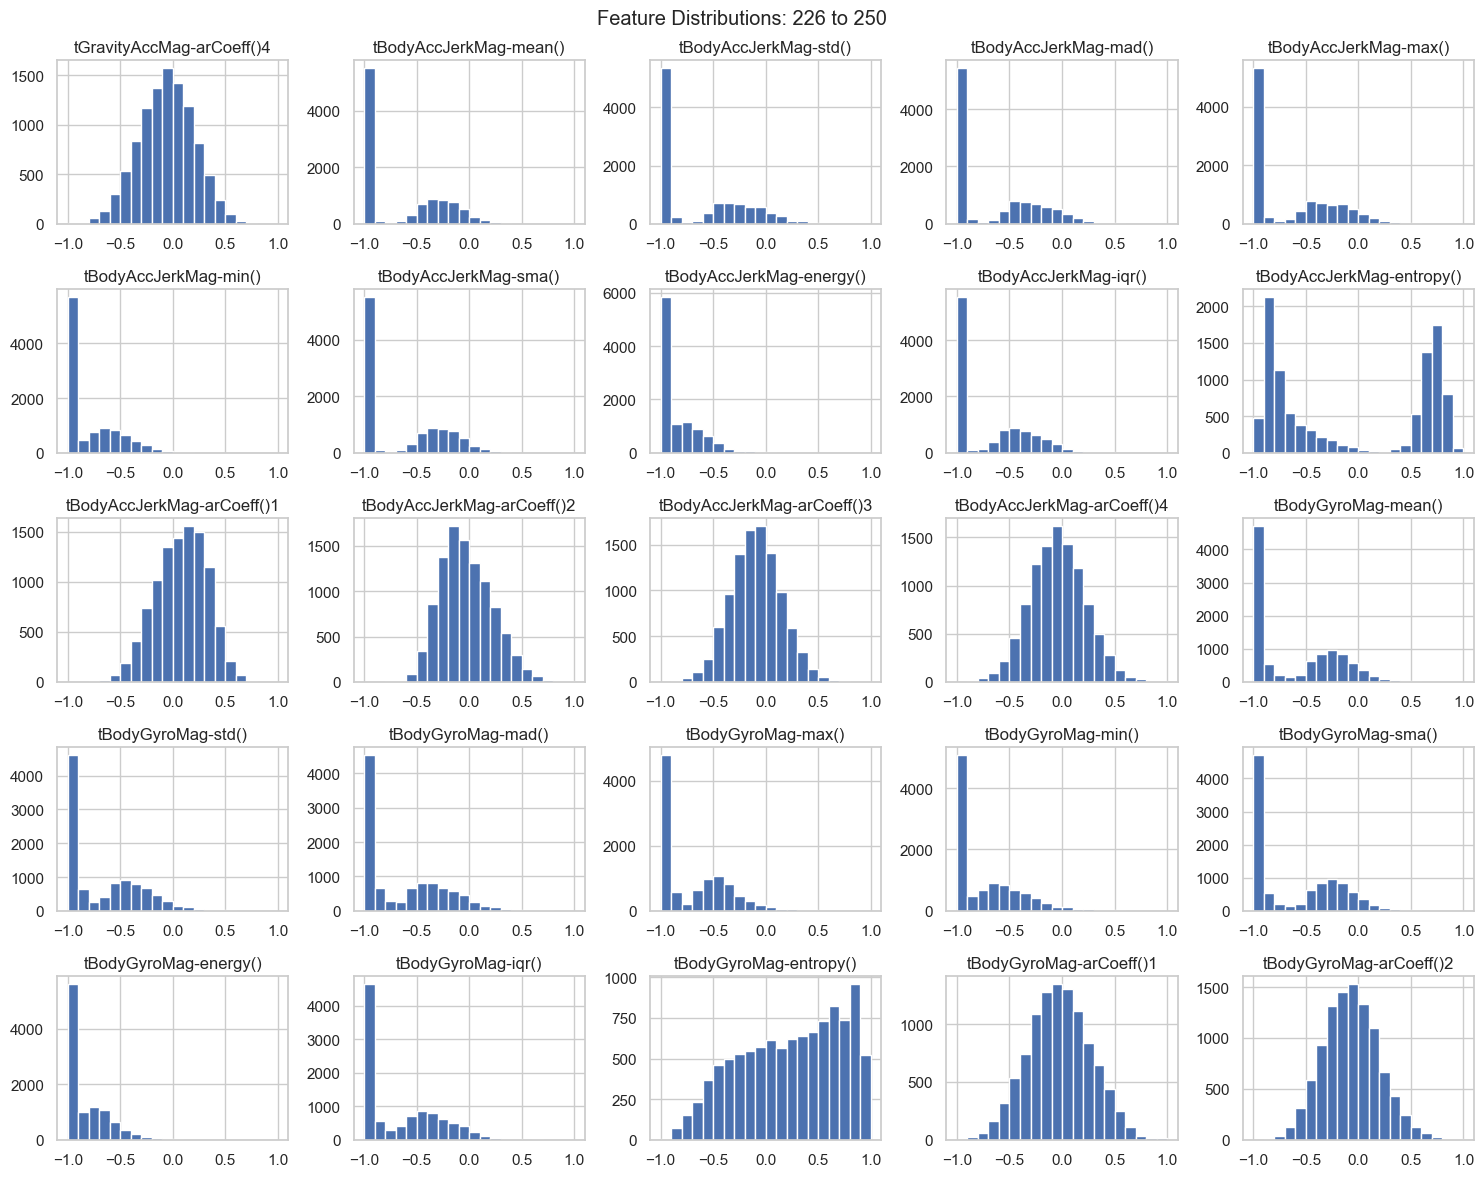

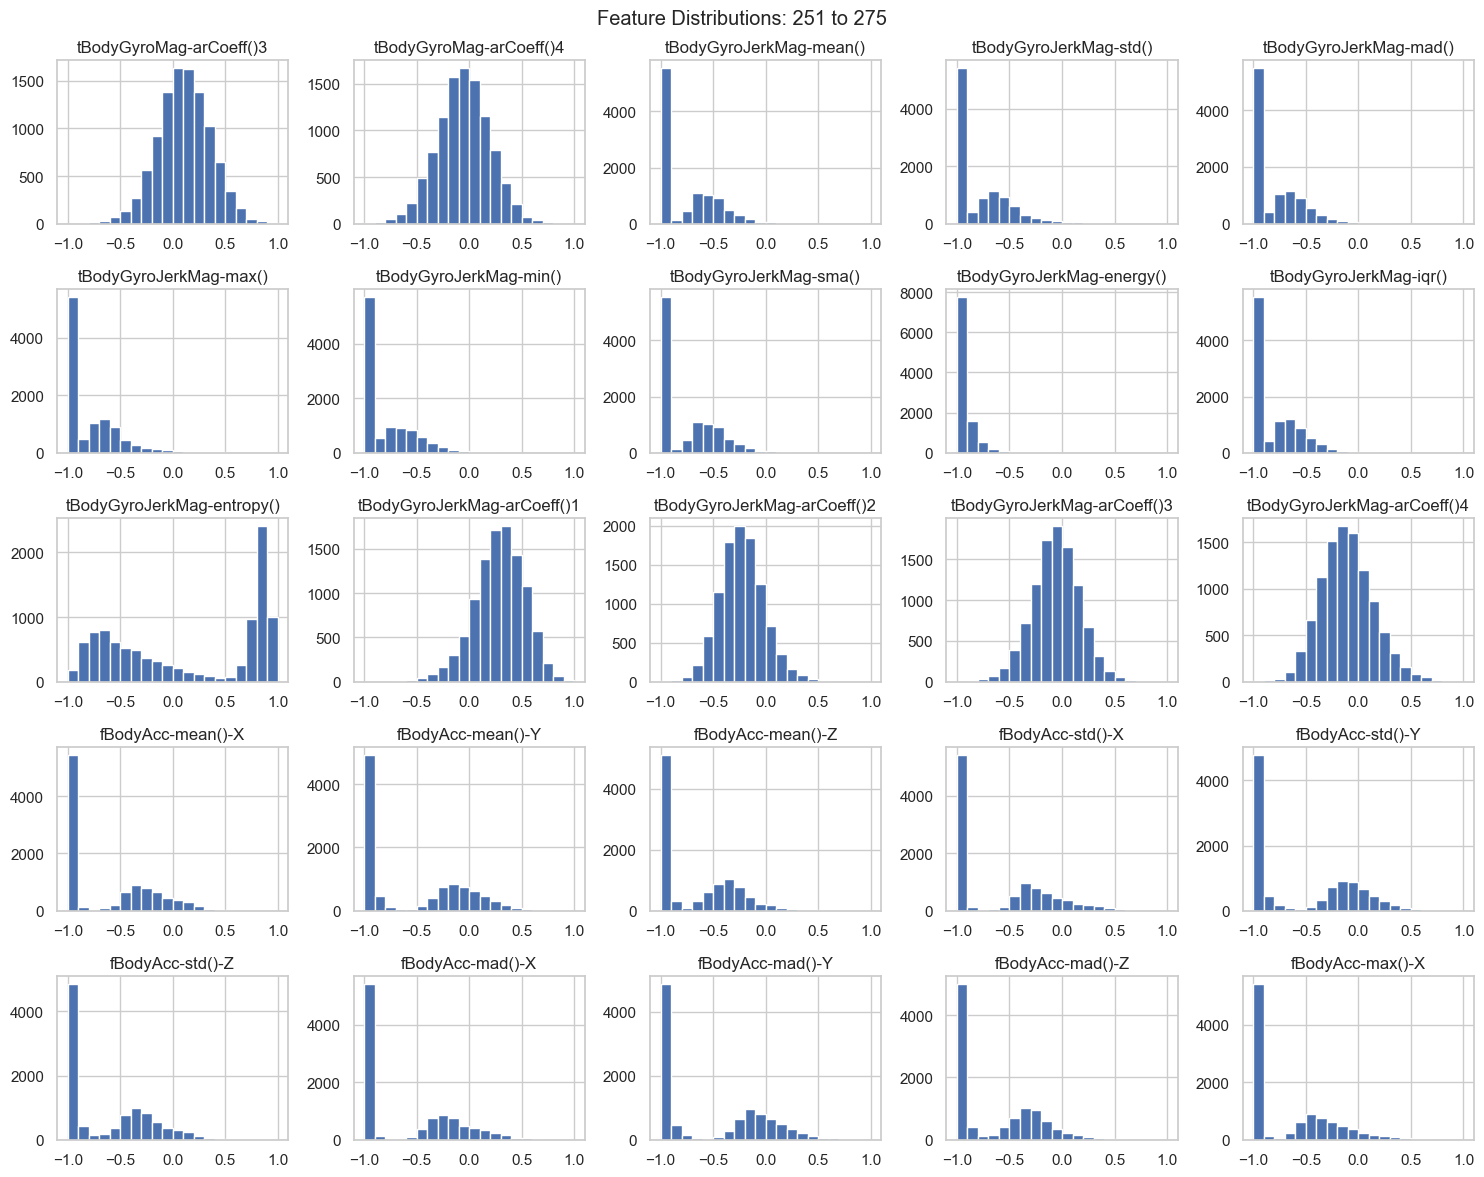

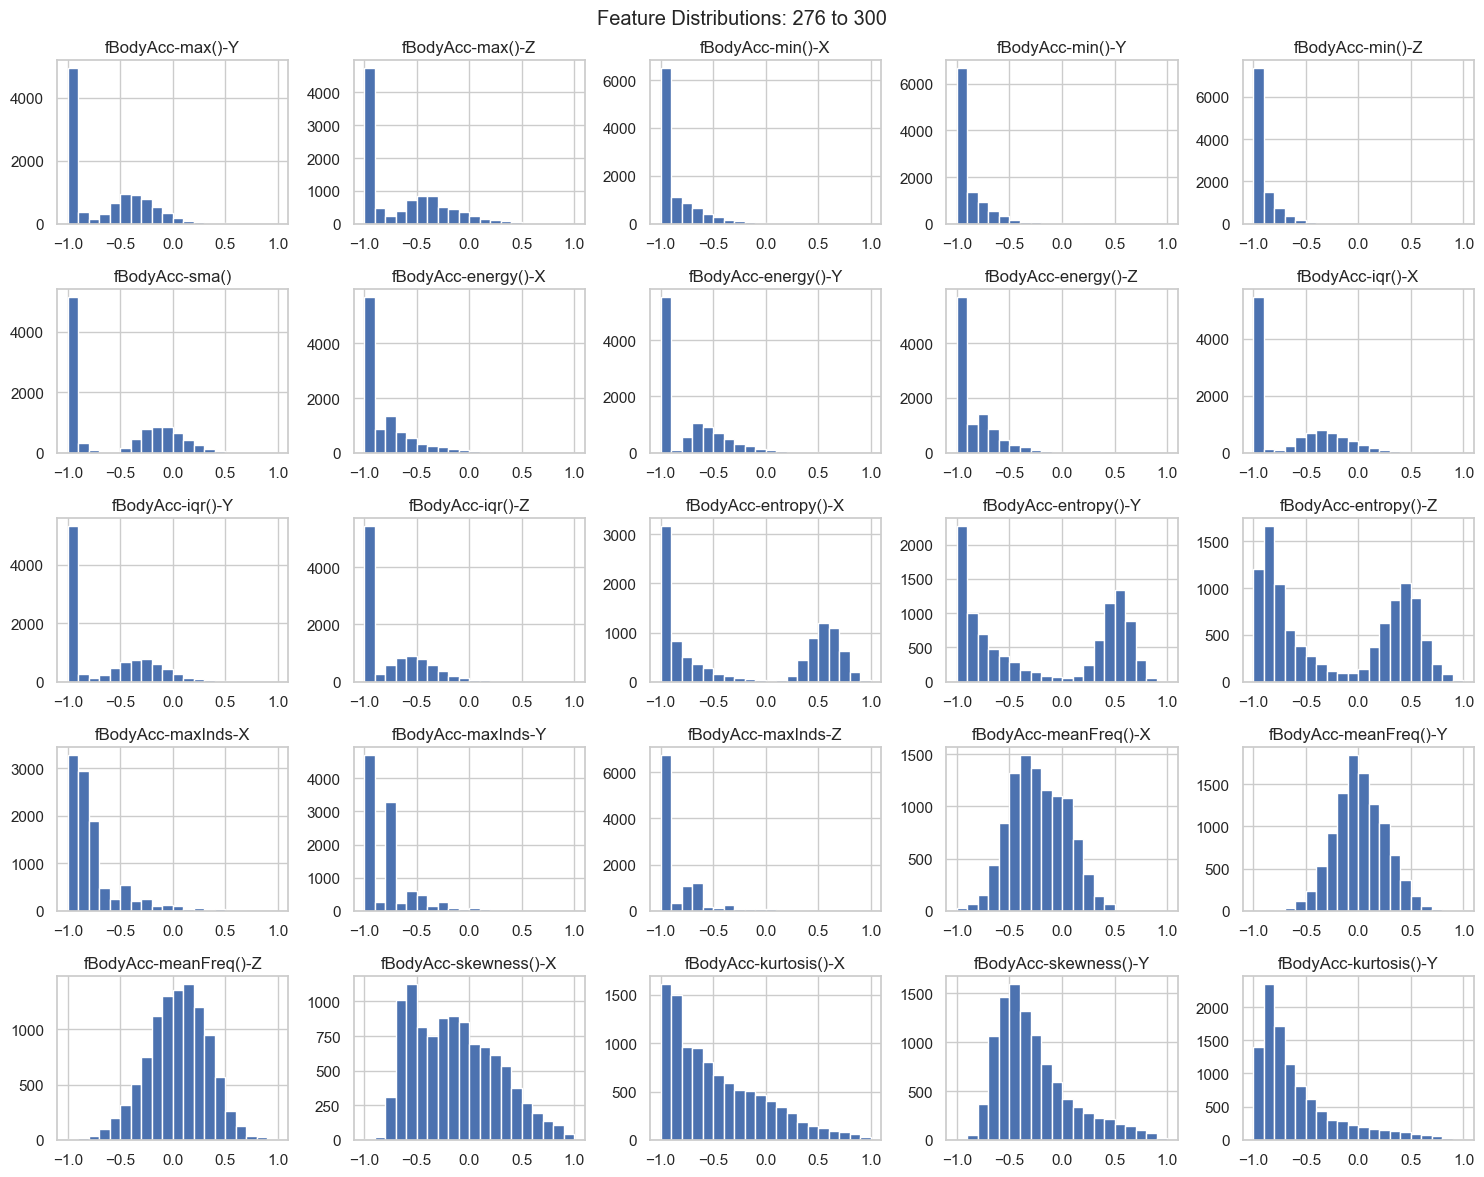

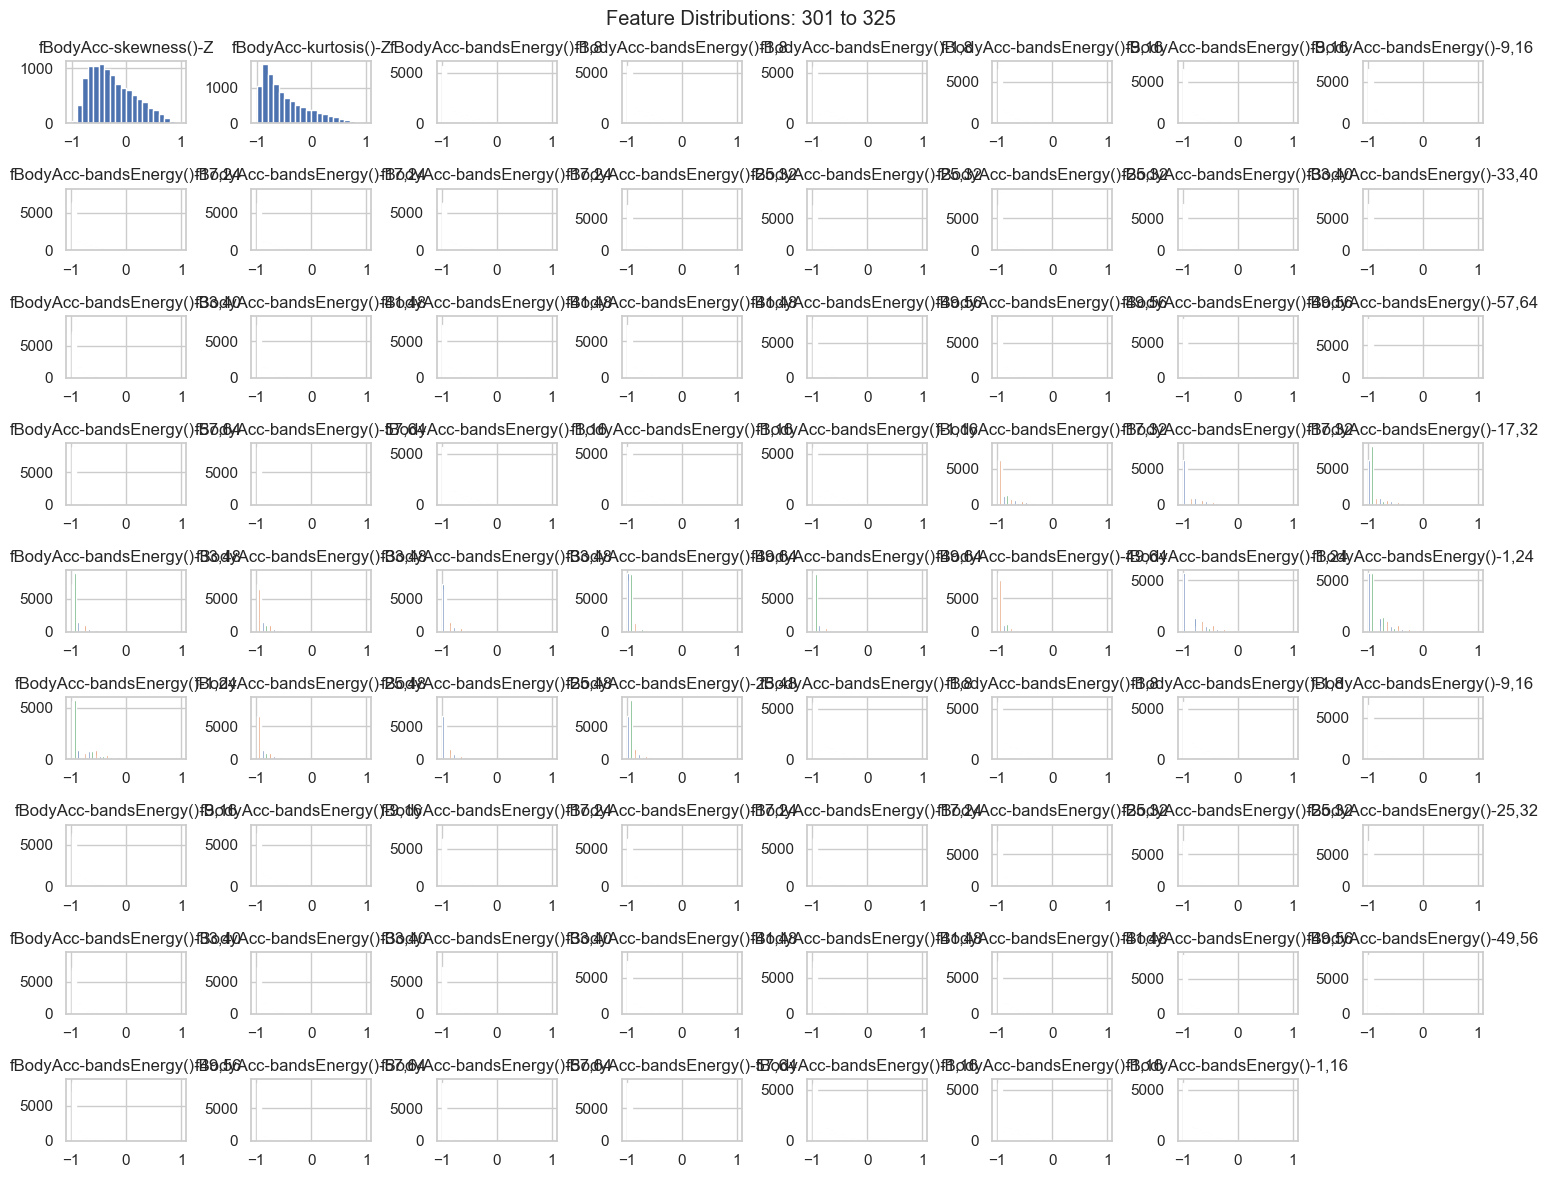

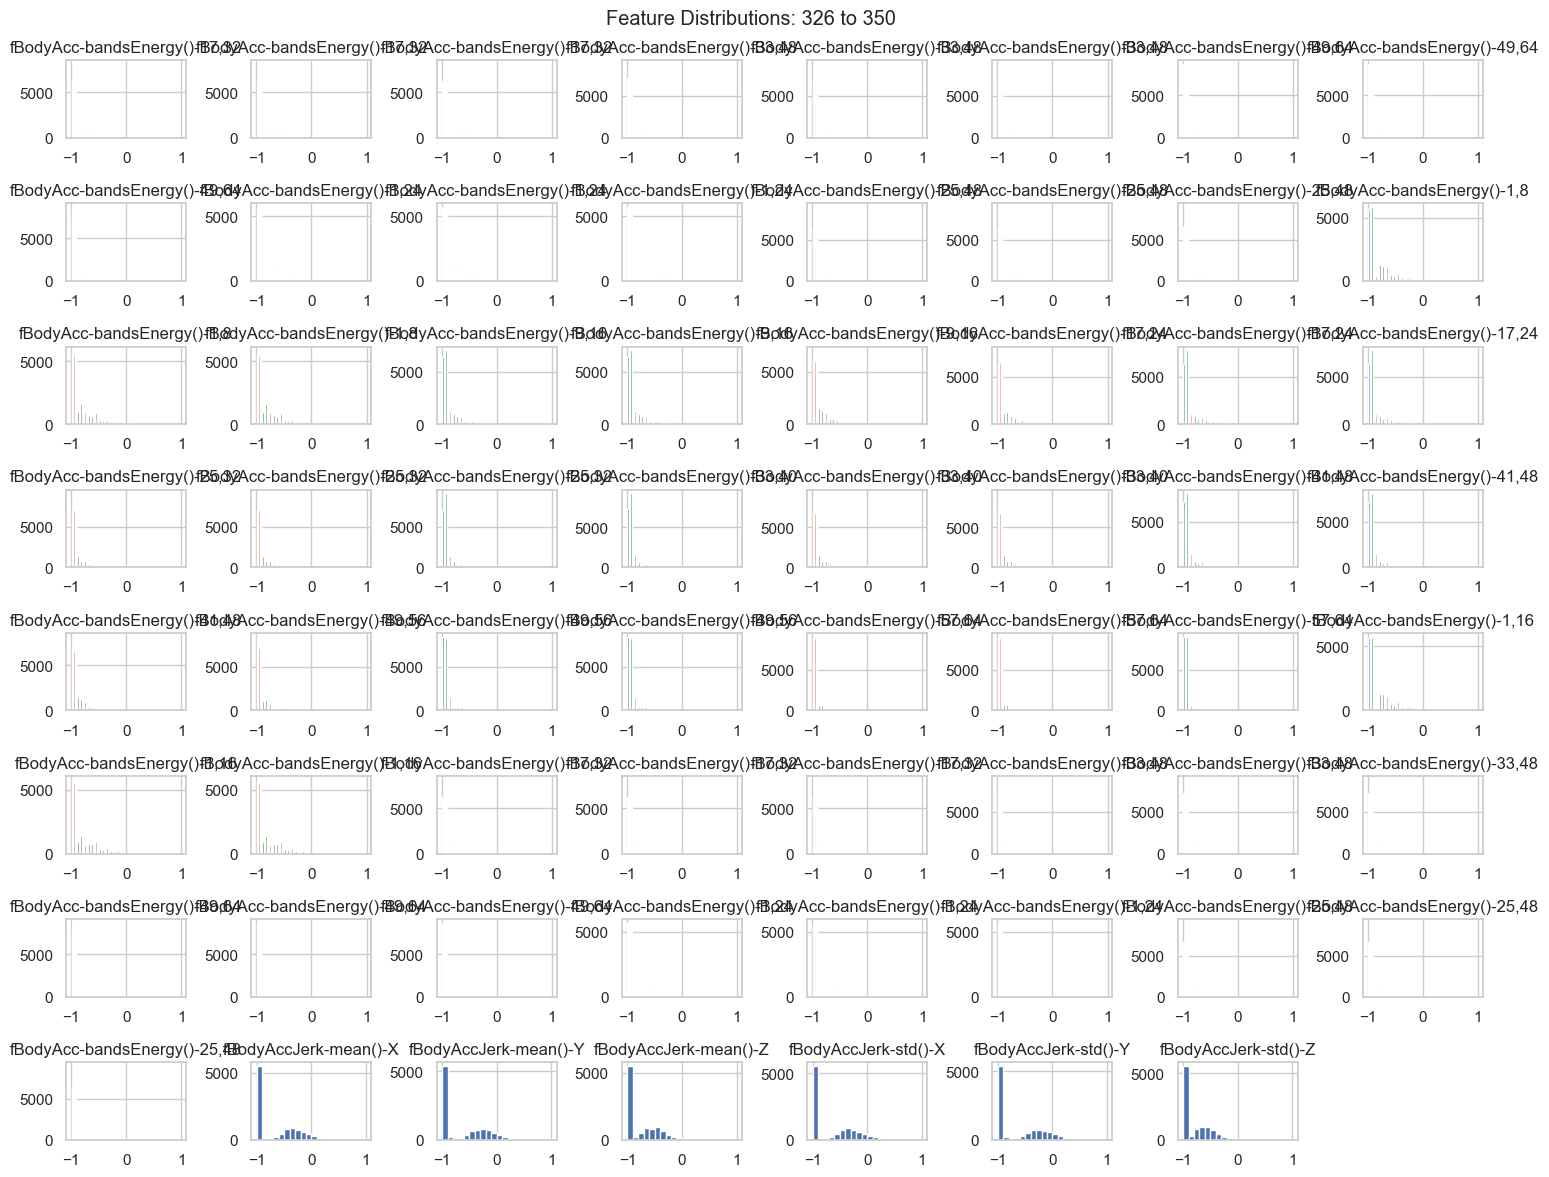

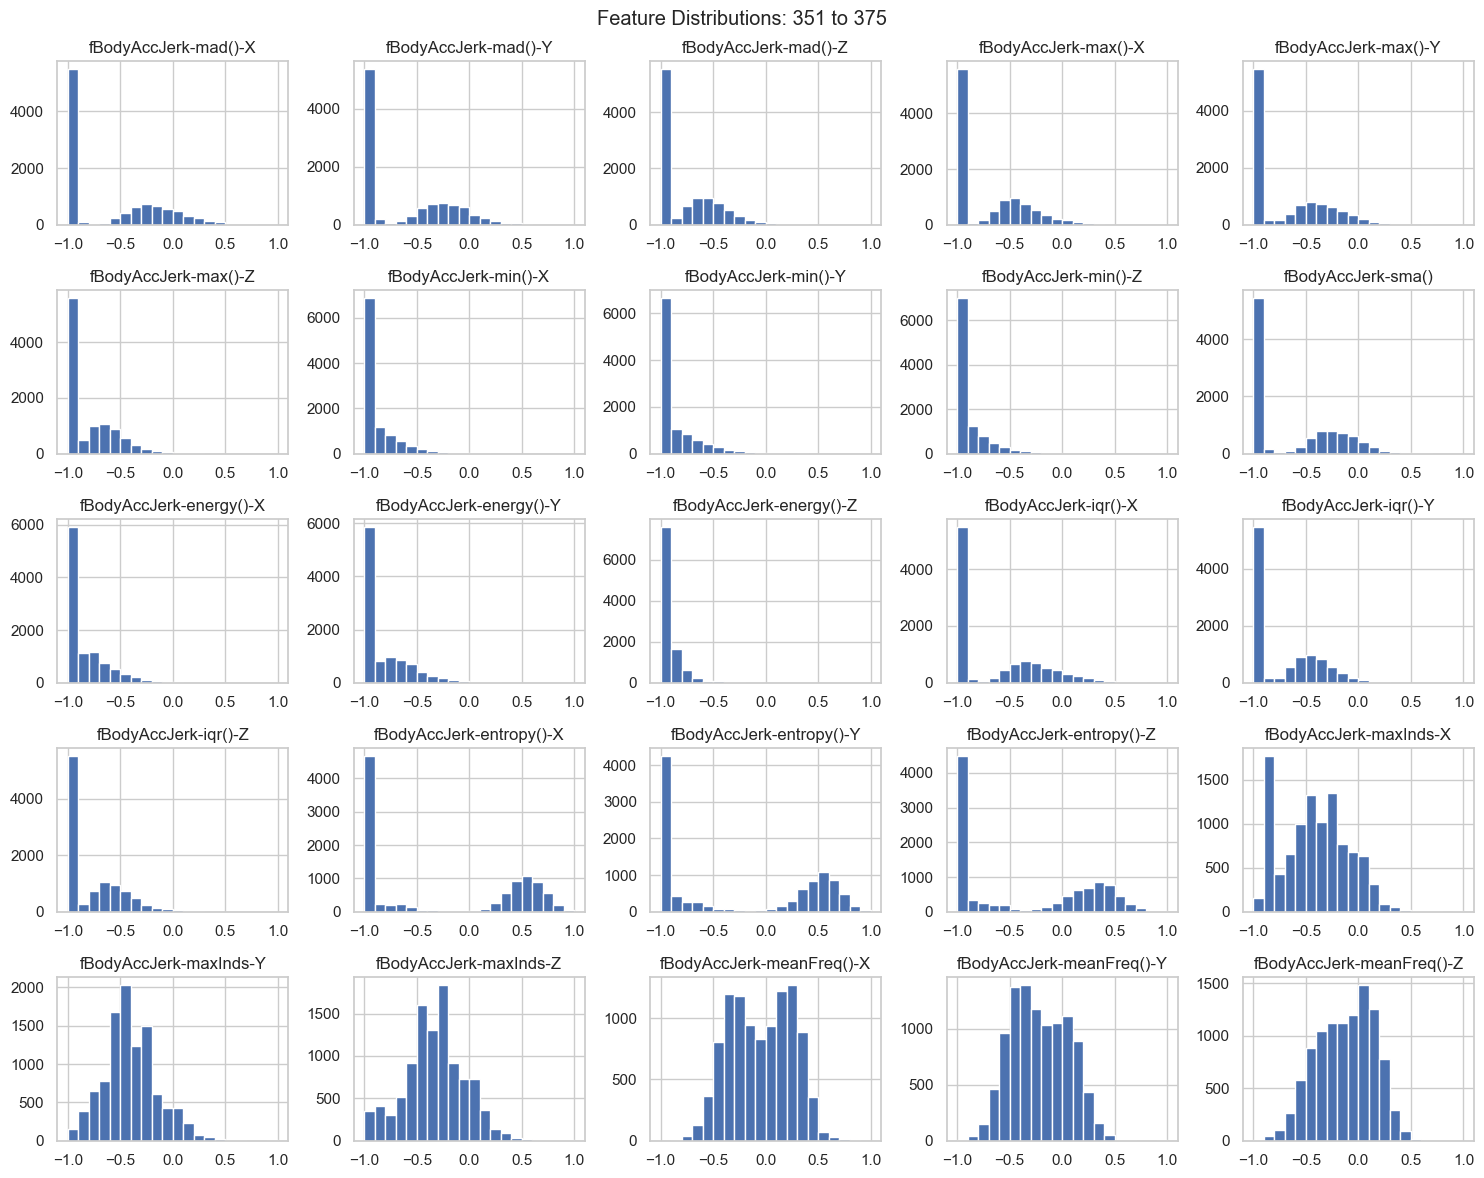

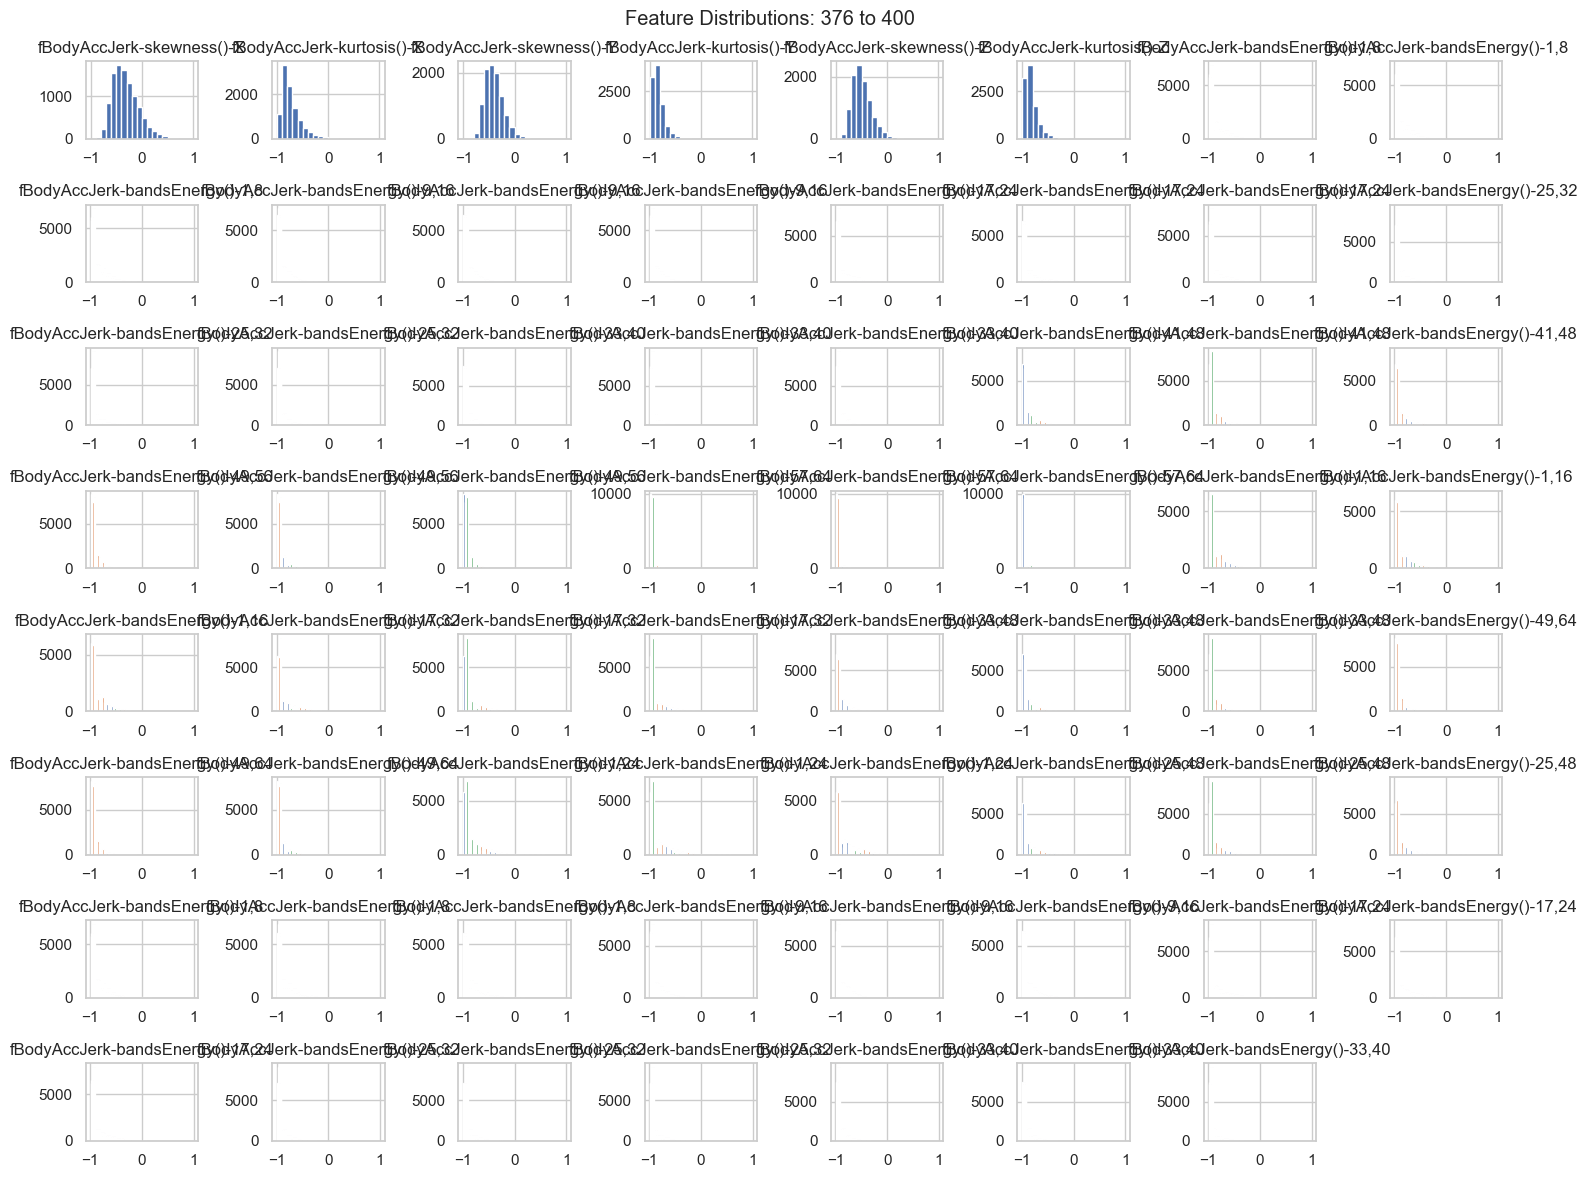

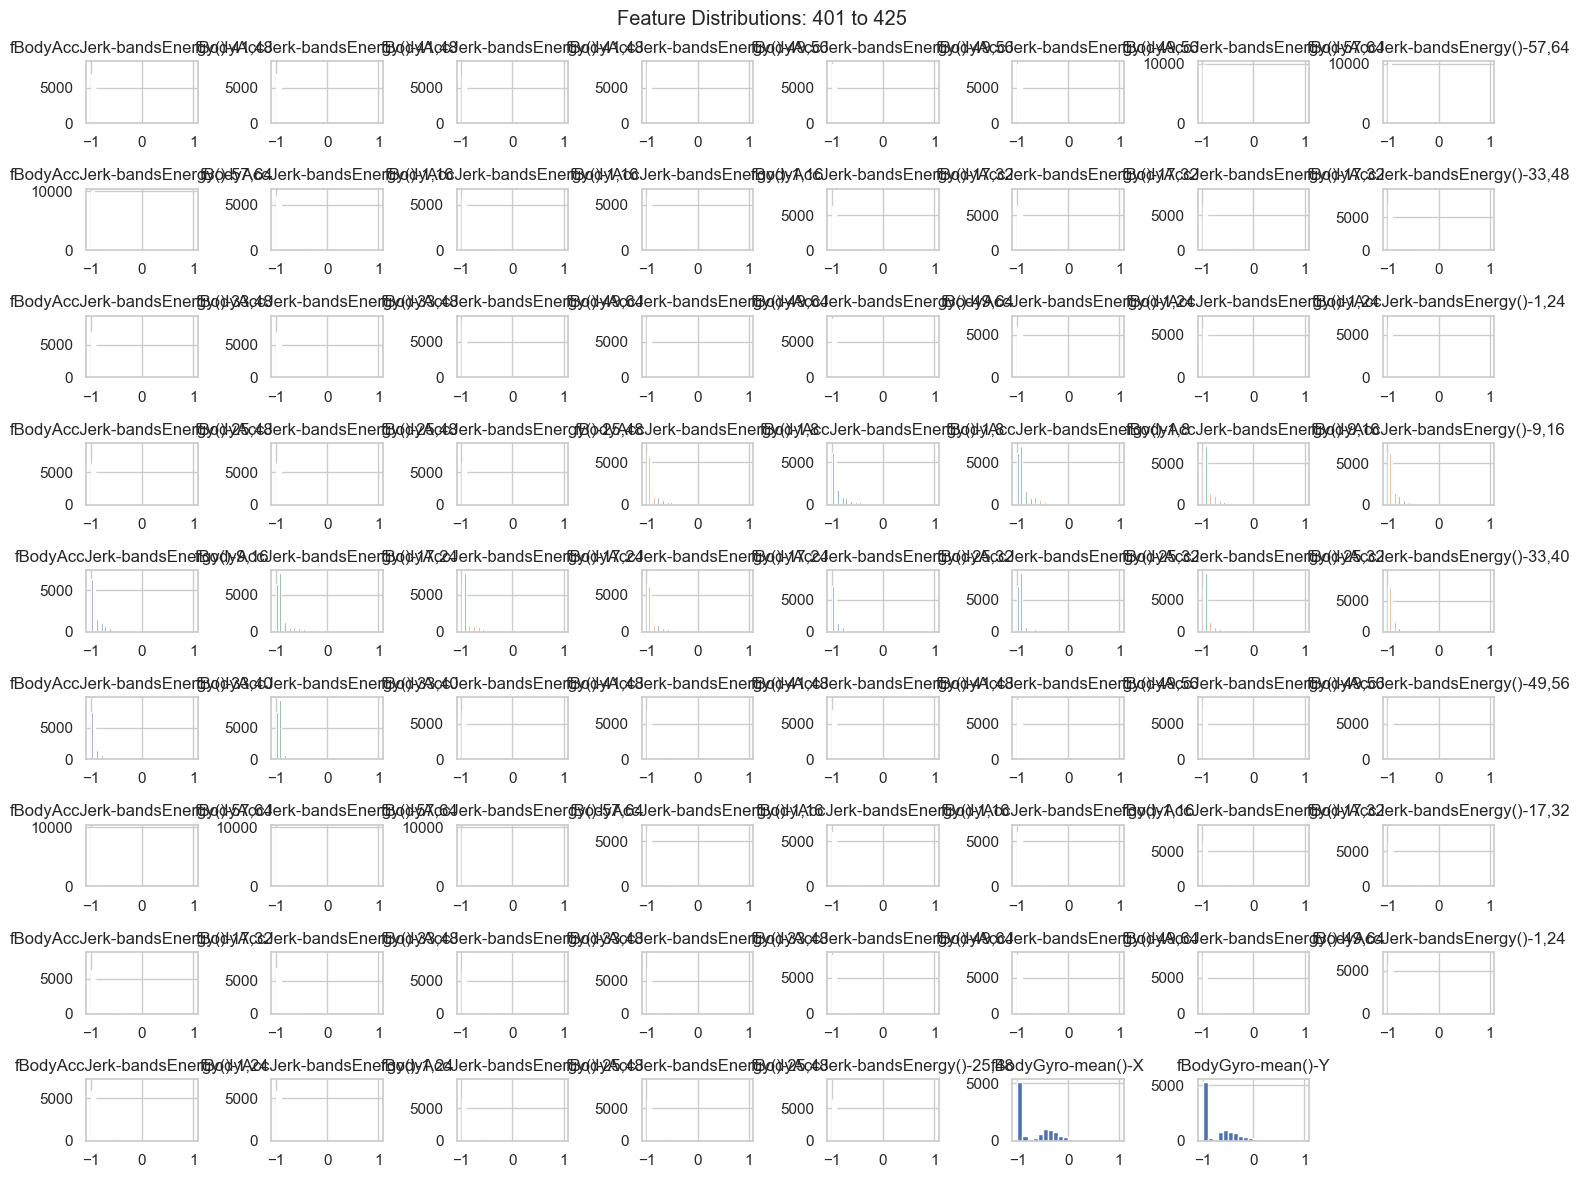

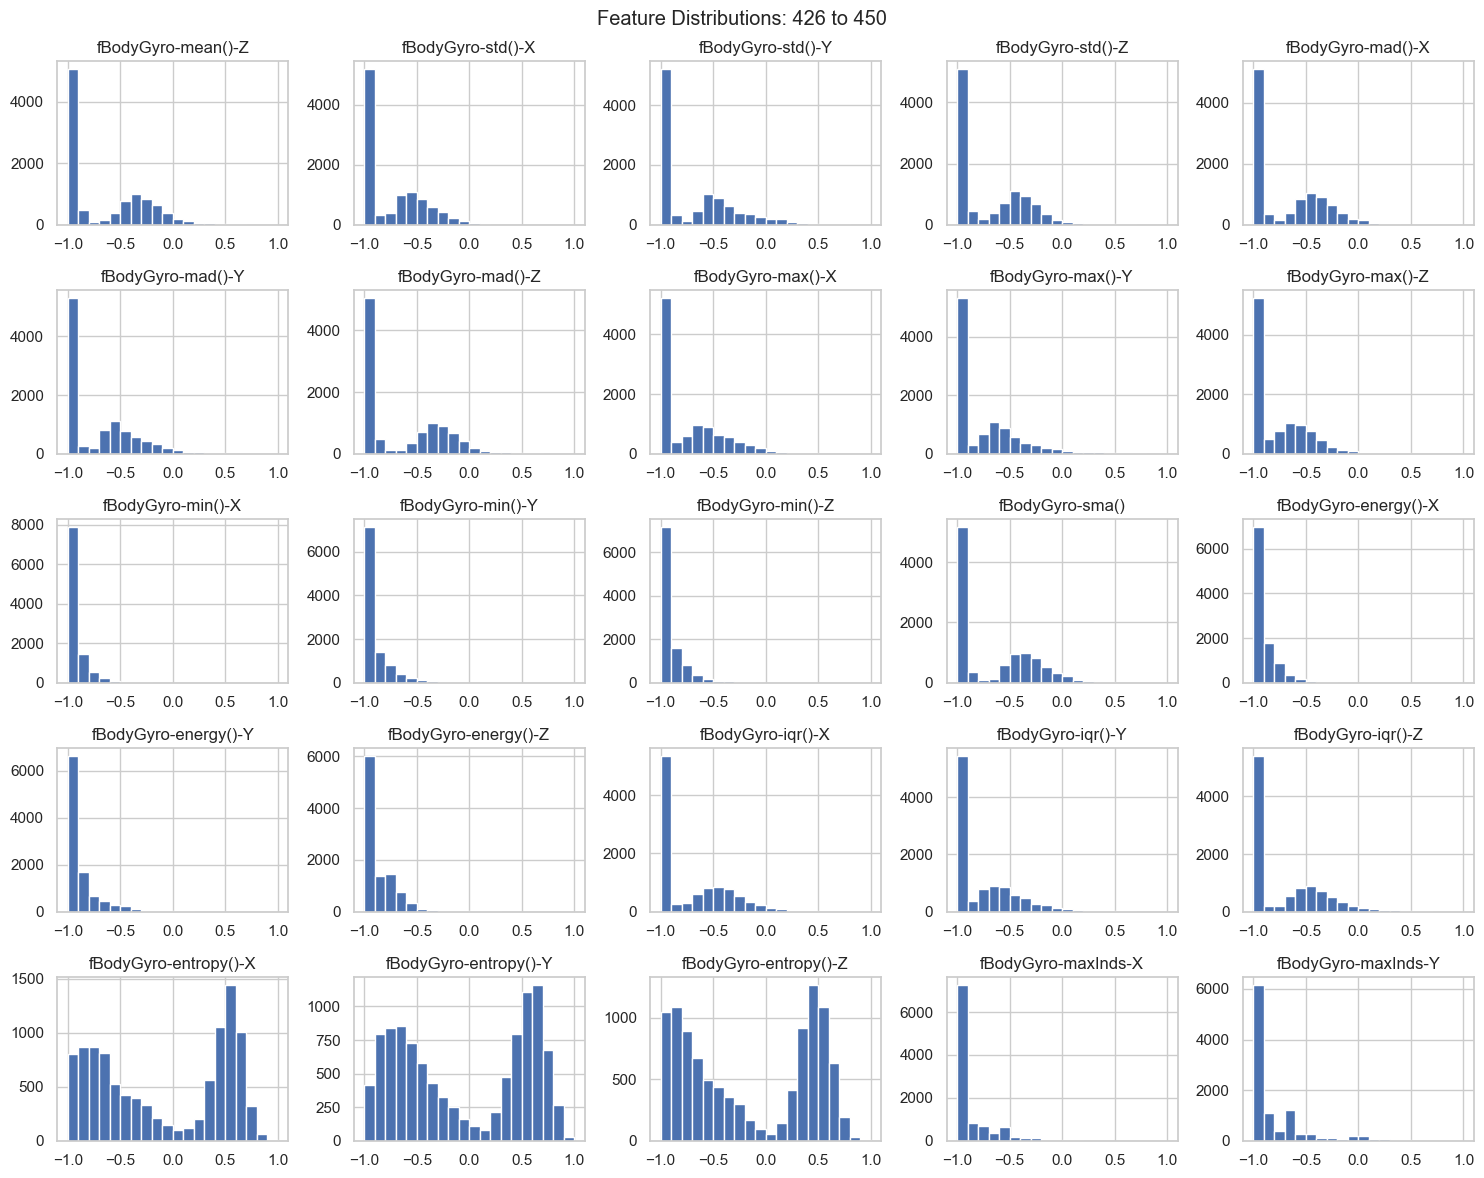

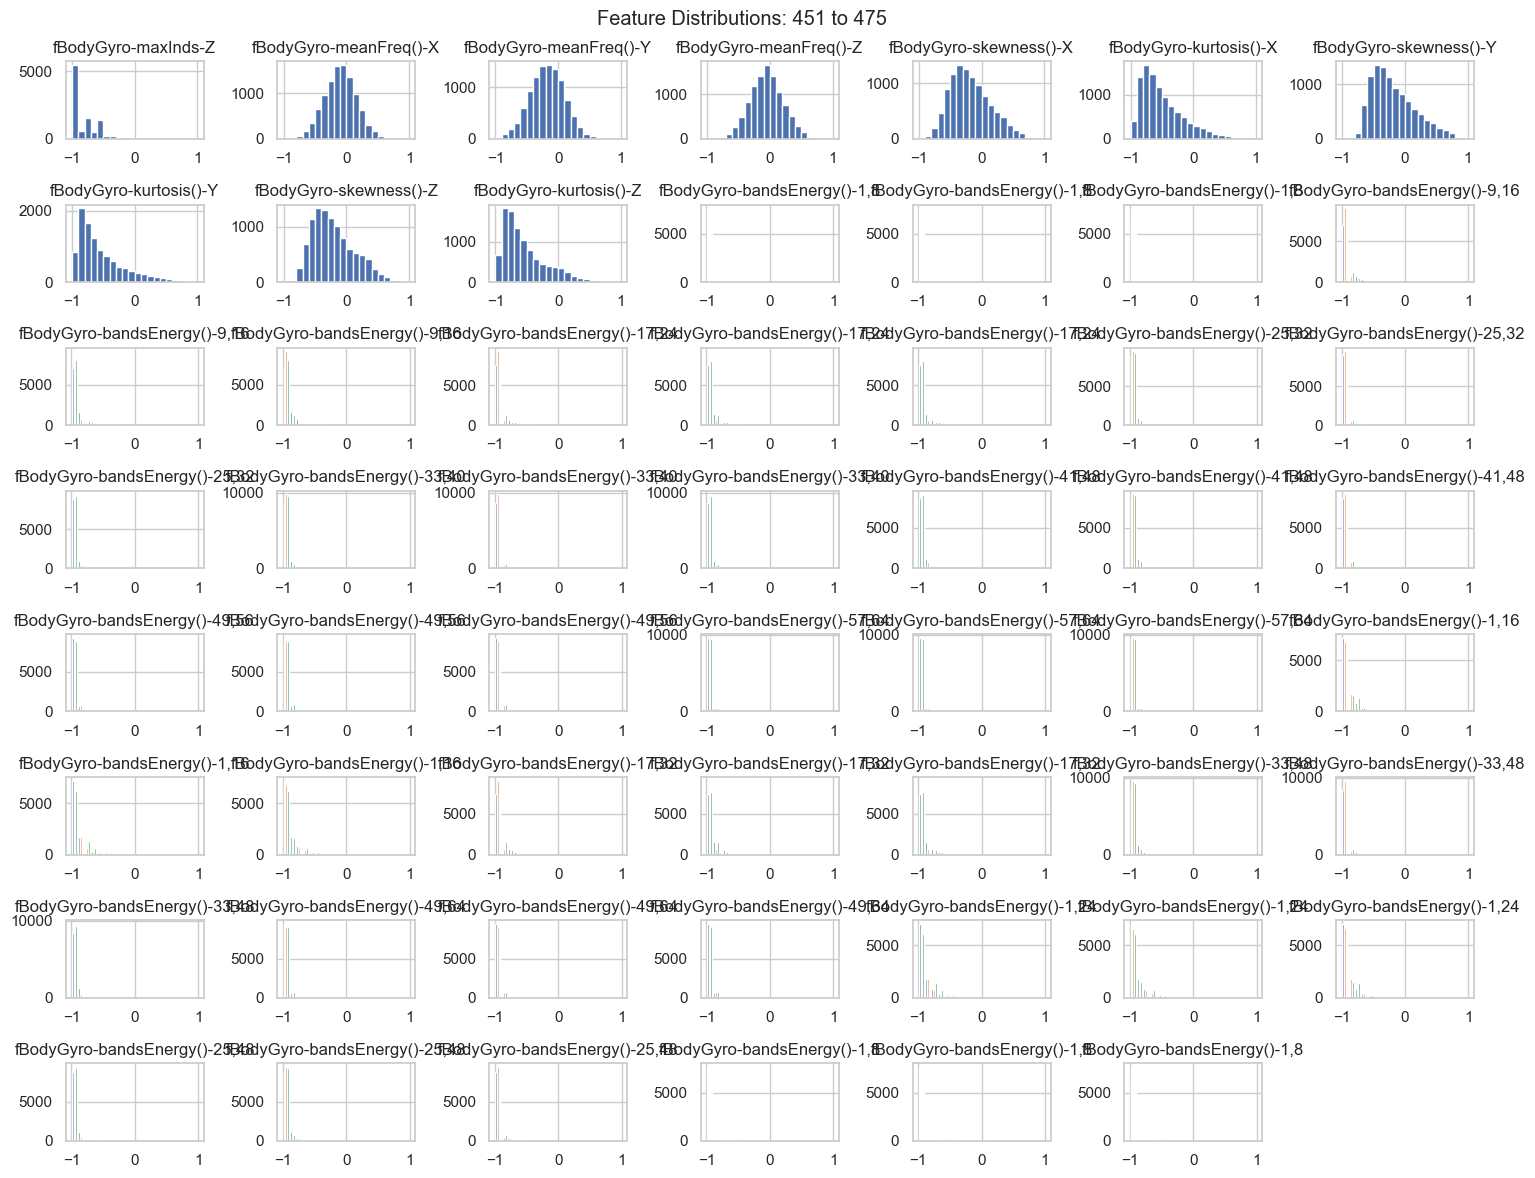

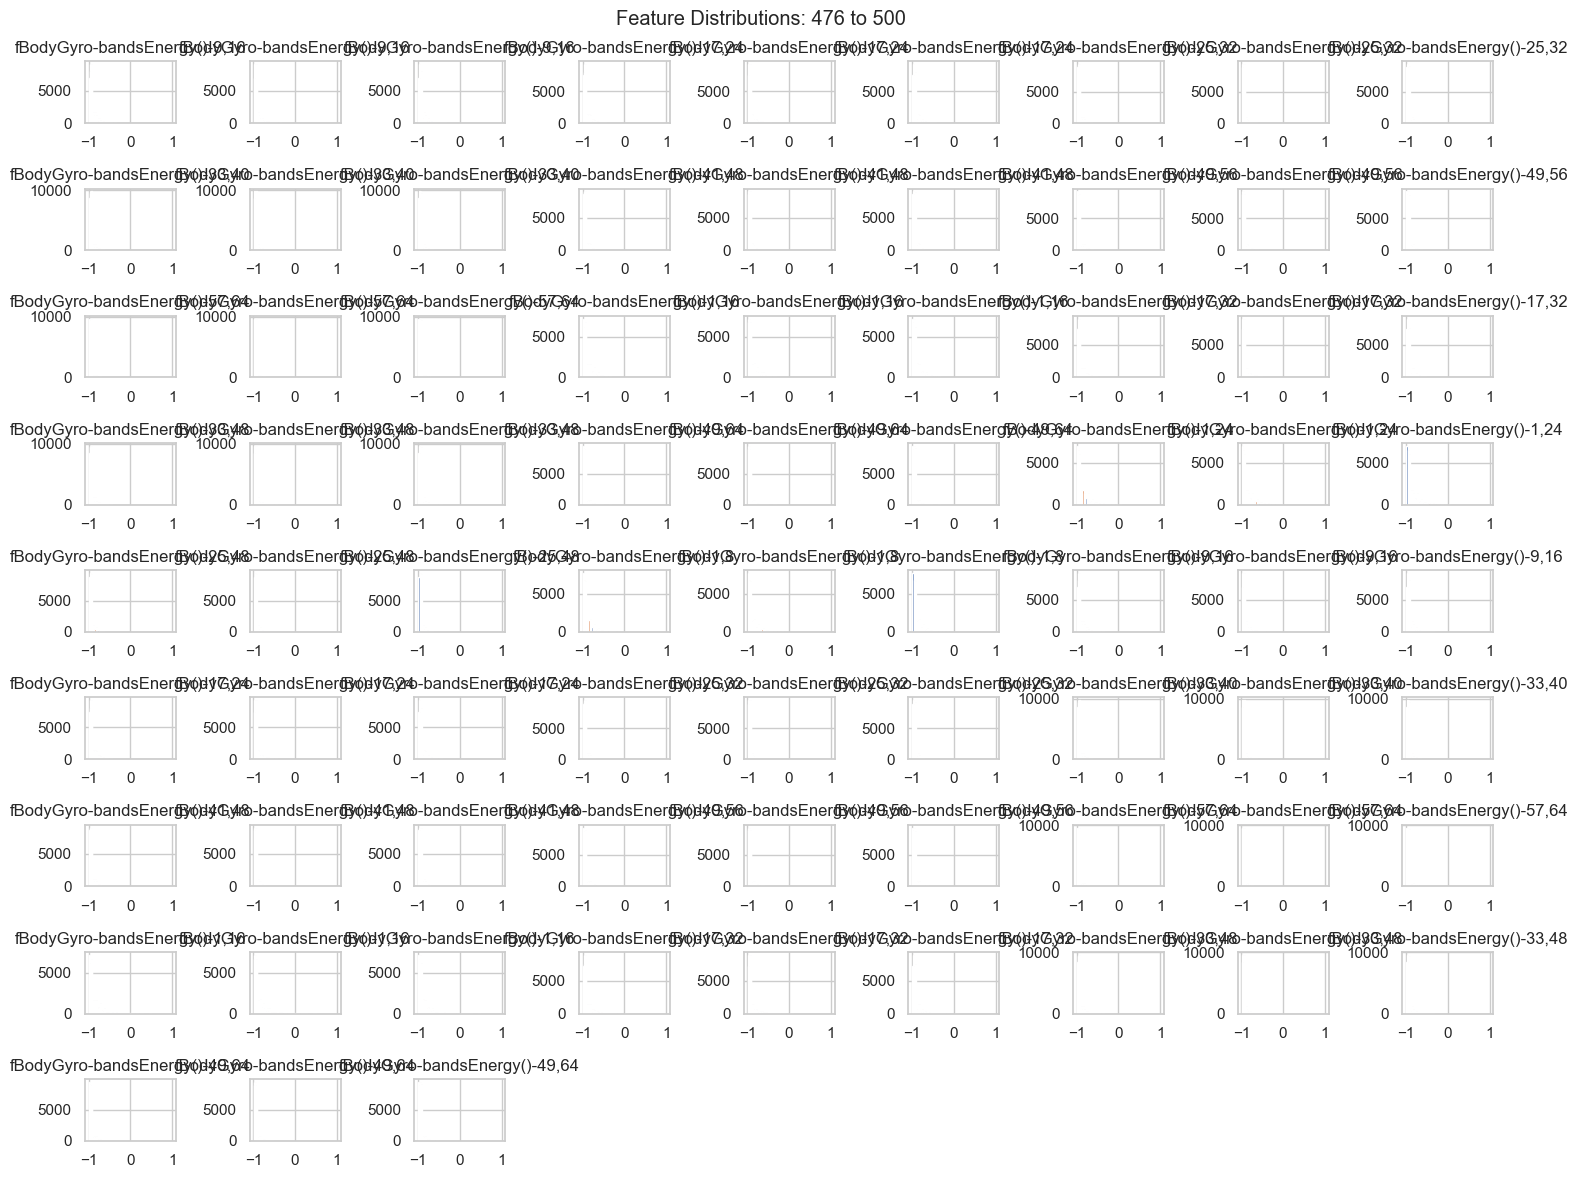

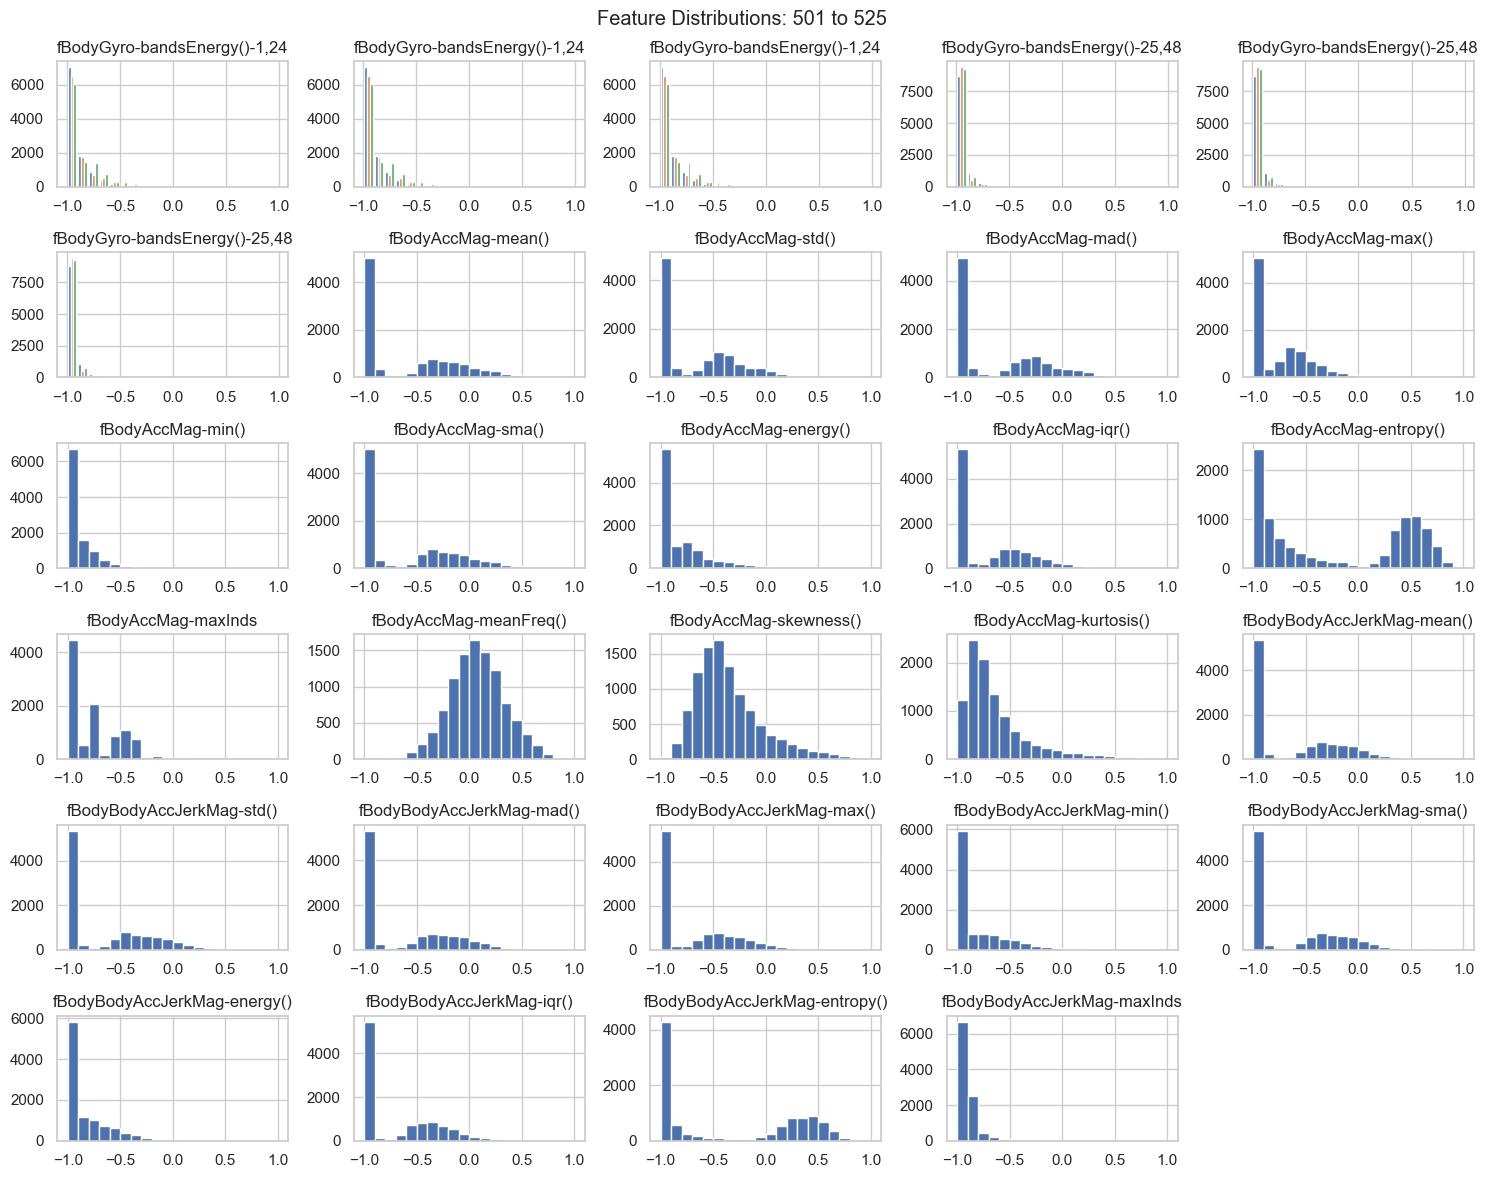

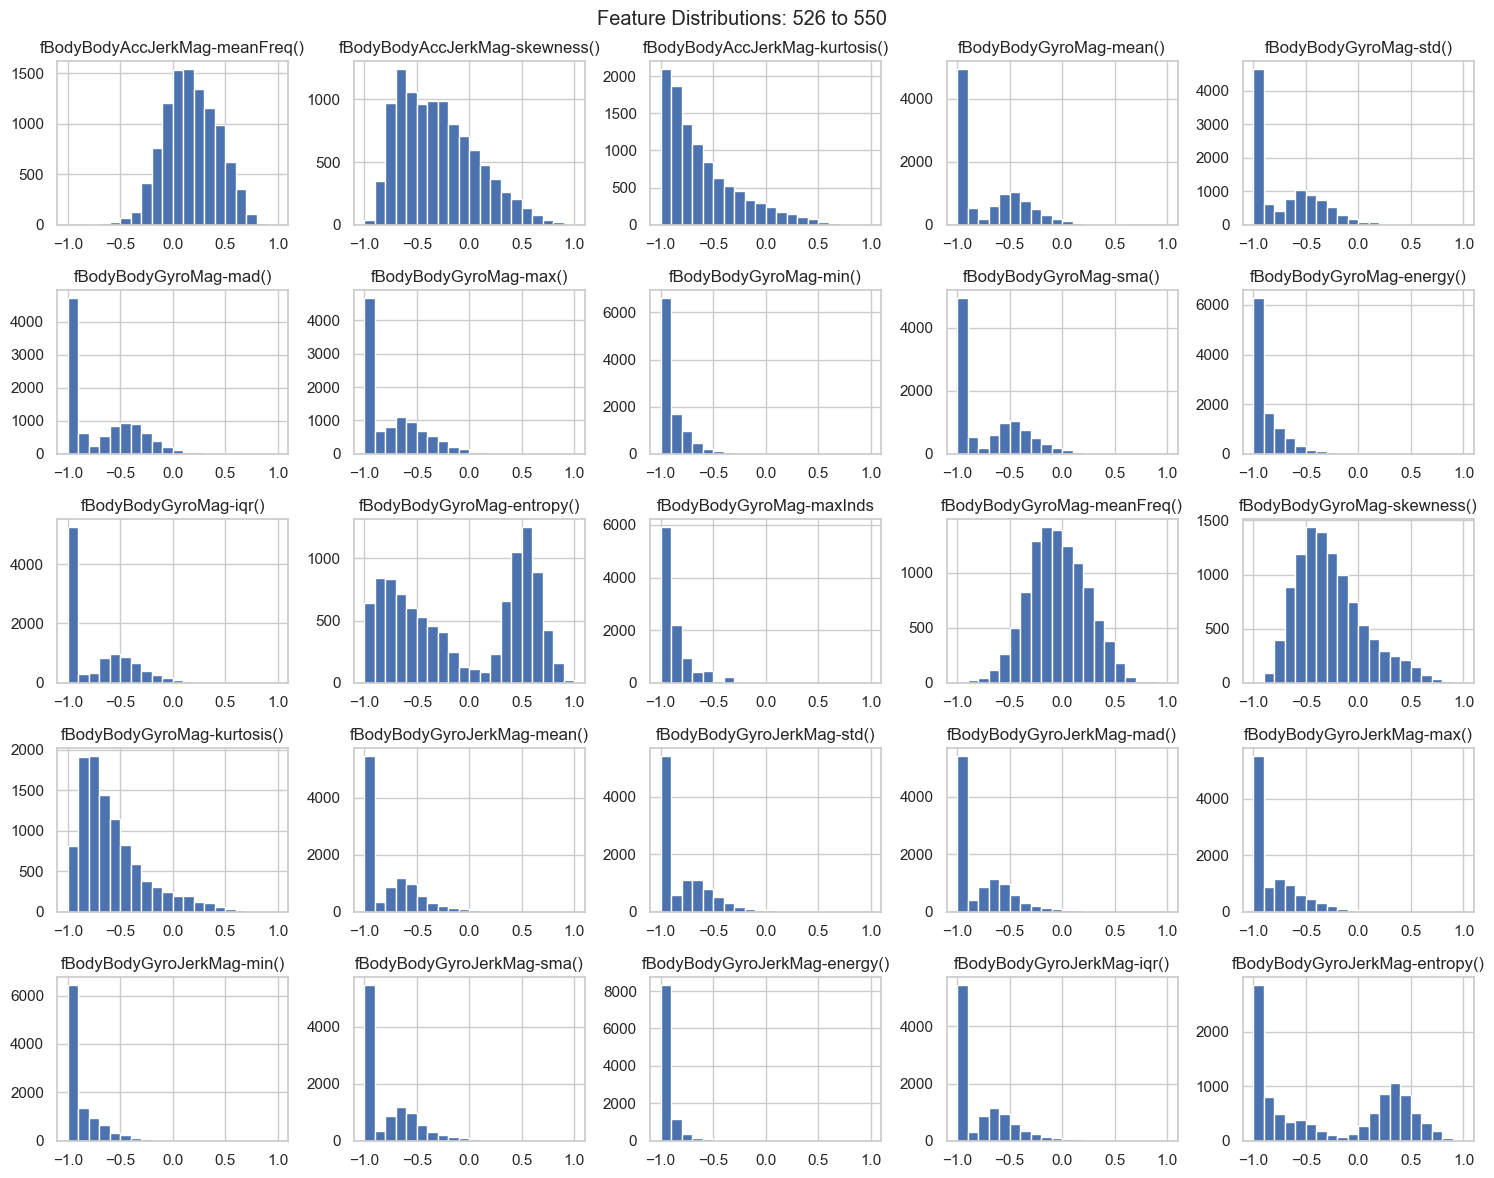

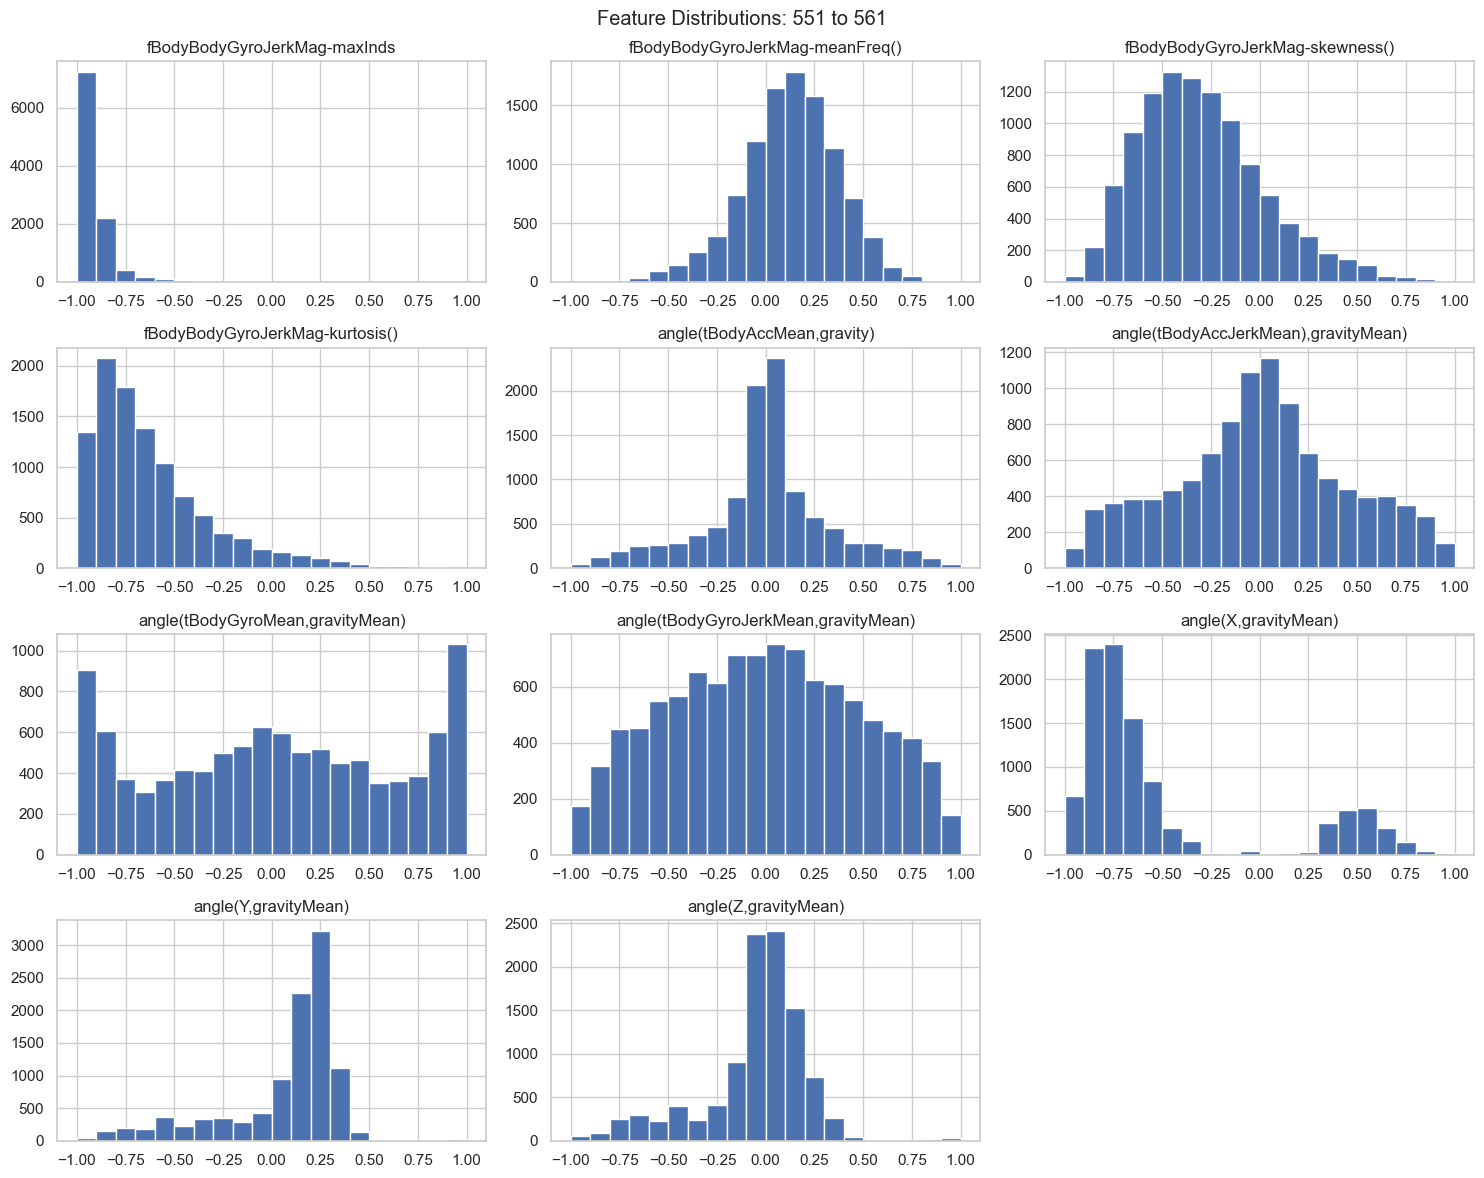

In [15]:
# Plot distributions for all numerical features in batches

features = X.columns

for start in range(0, len(features), 25):
    batch = features[start:start + 25]

    X[batch].hist(
        figsize=(15, 12),
        bins=20
    )

    plt.suptitle(
        f"Feature Distributions: {start + 1} to {start + len(batch)}"
    )

    plt.tight_layout()
    plt.show()

### Observation

The feature distributions show that the sensor-derived variables have different ranges and distribution patterns. Some features are concentrated around particular values, while others show wider variation. This indicates that the dataset contains diverse movement-related measurements and supports the need for appropriate preprocessing and scaling before model training.

# 13. Activity Distribution Visualization

A count plot is used to visually represent the number of samples belonging to each human activity.

This helps understand the distribution of the six activity classes in the dataset.

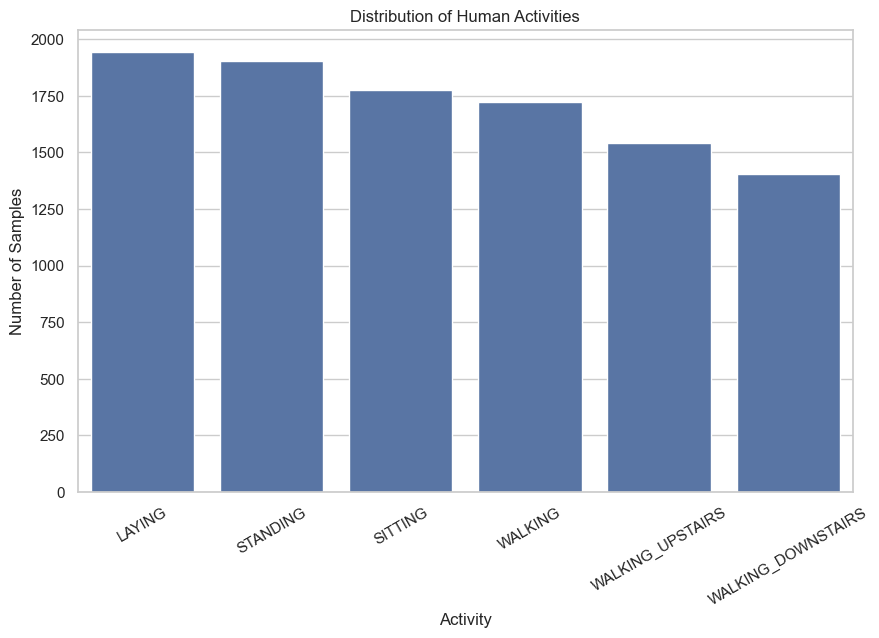

In [16]:
plt.figure(figsize=(10, 6))

sns.countplot(
    x=y_named,
    order=y_named.value_counts().index
)

plt.title("Distribution of Human Activities")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)

plt.show()

### Observation

The activity distribution plot shows that each of the six activities has a substantial number of observations. This provides sufficient examples for training a multi-class classification model.

# 15. Feature Distribution Across Activities

A box plot is used to examine how a representative sensor feature varies across the different human activities.

Box plots help visualise the median, spread, and possible variation of the feature for each activity.

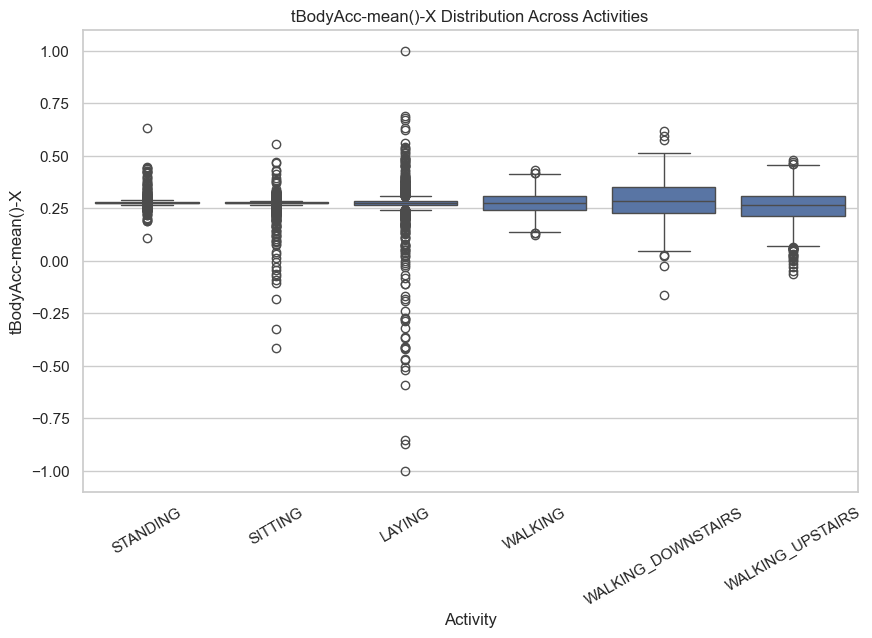

In [17]:
plot_feature = selected_features[0]

plt.figure(figsize=(10, 6))

sns.boxplot(
    x=y_named,
    y=X[plot_feature]
)

plt.title(
    f"{plot_feature} Distribution Across Activities"
)

plt.xlabel("Activity")
plt.ylabel(plot_feature)
plt.xticks(rotation=30)

plt.show()

### Observation

The box plot shows that the selected sensor feature has different distributions across human activities. Differences in the median and spread between activities indicate that sensor measurements can help distinguish between activity classes.

# 16. Correlation Analysis

The correlation between a selected group of representative features is calculated and visualised using a heatmap.

Correlation analysis helps identify relationships between sensor-derived features.

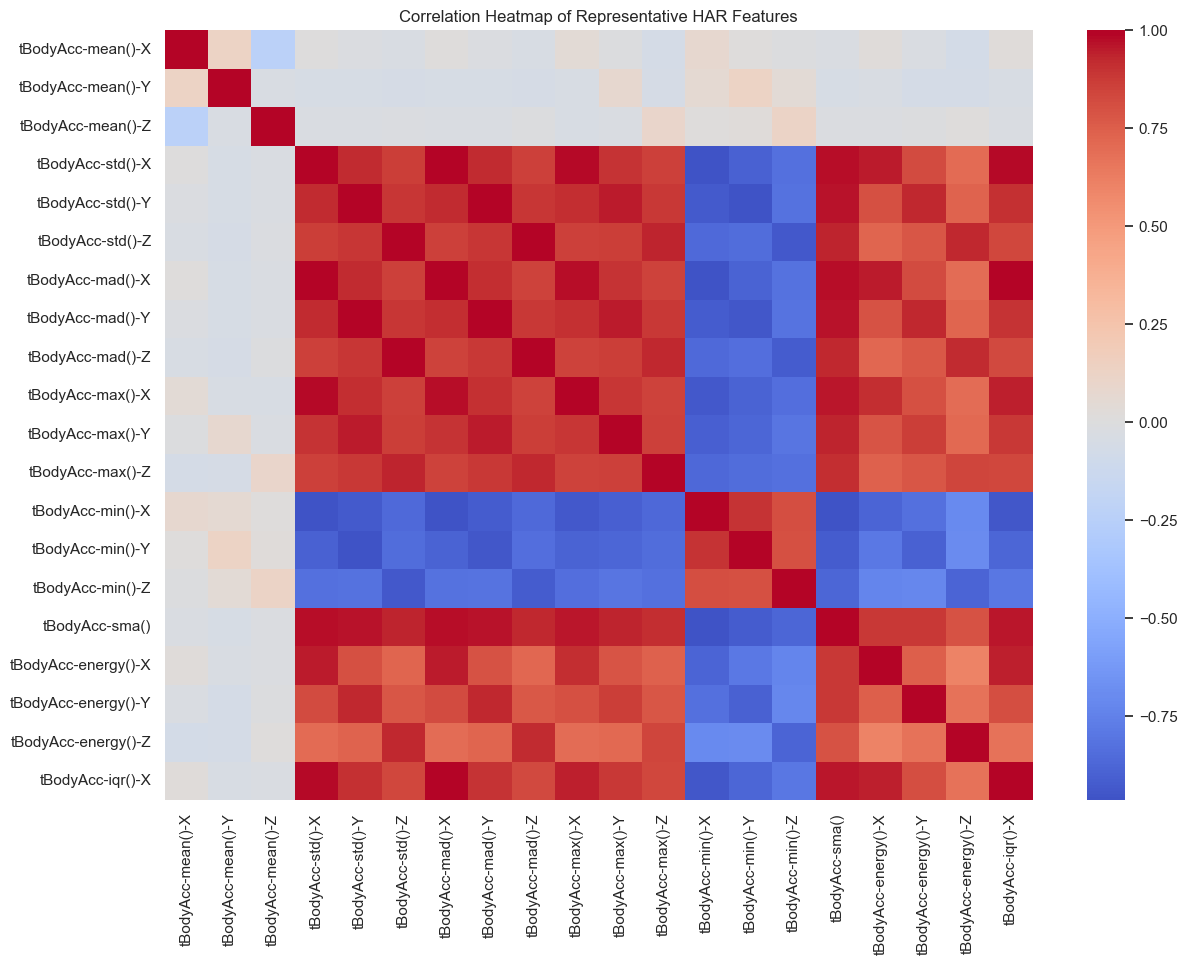

In [18]:
heatmap_features = feature_names[:20]

plt.figure(figsize=(14, 10))

correlation = X[heatmap_features].corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Representative HAR Features")
plt.show()

### Observation

The correlation heatmap shows relationships among the selected sensor features. Some features are strongly correlated, indicating that related sensor measurements may contain overlapping information.

## Feature-Target Relationship

Scatter plots are used to examine the relationship between selected sensor features and the activity classes.

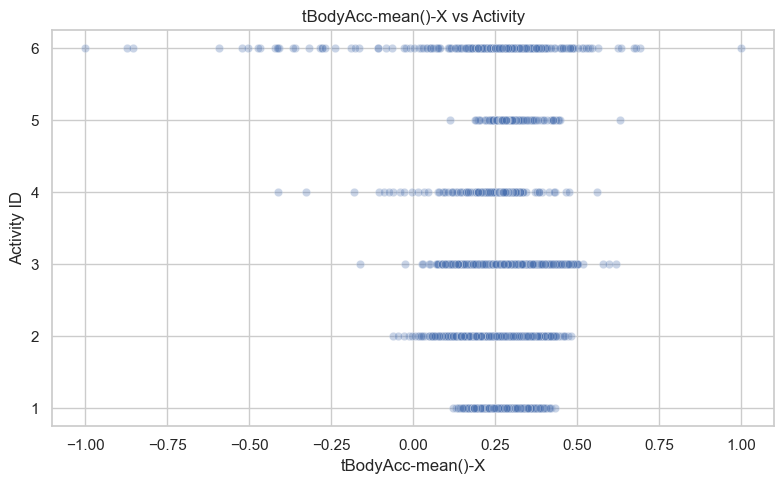

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=X["tBodyAcc-mean()-X"],
    y=y,
    alpha=0.3
)

plt.title("tBodyAcc-mean()-X vs Activity")
plt.xlabel("tBodyAcc-mean()-X")
plt.ylabel("Activity ID")
plt.tight_layout()
plt.show()

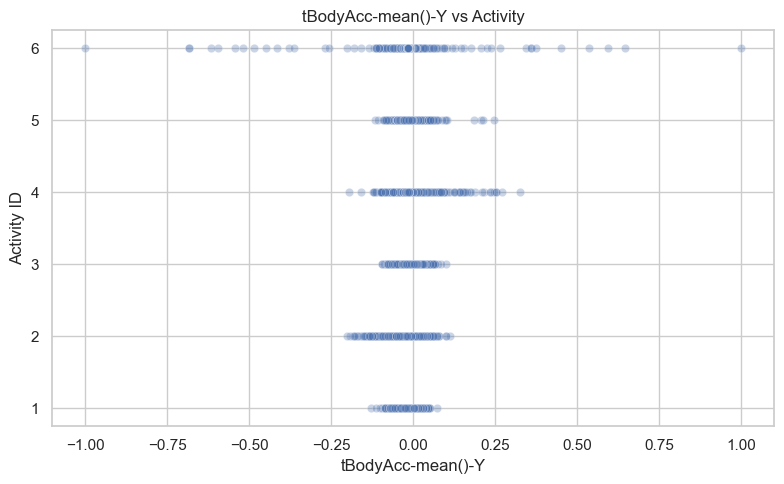

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=X["tBodyAcc-mean()-Y"],
    y=y,
    alpha=0.3
)

plt.title("tBodyAcc-mean()-Y vs Activity")
plt.xlabel("tBodyAcc-mean()-Y")
plt.ylabel("Activity ID")
plt.tight_layout()
plt.show()

### Observation

The scatter plots show how the selected body-acceleration features vary across the different activity classes. The overlap between classes indicates that individual sensor features alone may not be sufficient to clearly separate all activities, which supports the use of multiple features for classification.

## Feature Engineering

A new BodyAcc_Mean_Magnitude feature is created by combining the X, Y, and Z components of the mean body acceleration. This magnitude represents the overall acceleration level independent of direction and may provide additional information for distinguishing different human activities.

In [21]:
# Create an engineered feature representing the overall
# magnitude of mean body acceleration

X["BodyAcc_Mean_Magnitude"] = np.sqrt(
    X["tBodyAcc-mean()-X"]**2 +
    X["tBodyAcc-mean()-Y"]**2 +
    X["tBodyAcc-mean()-Z"]**2
)

X[["BodyAcc_Mean_Magnitude"]].head()

,BodyAcc_Mean_Magnitude
0,0.318366
1,0.305030
2,0.302421
3,0.306306
4,0.300177


### Engineered Feature Distribution

The distribution of the newly engineered BodyAcc_Mean_Magnitude feature is visualised to understand its range and variation across the dataset.

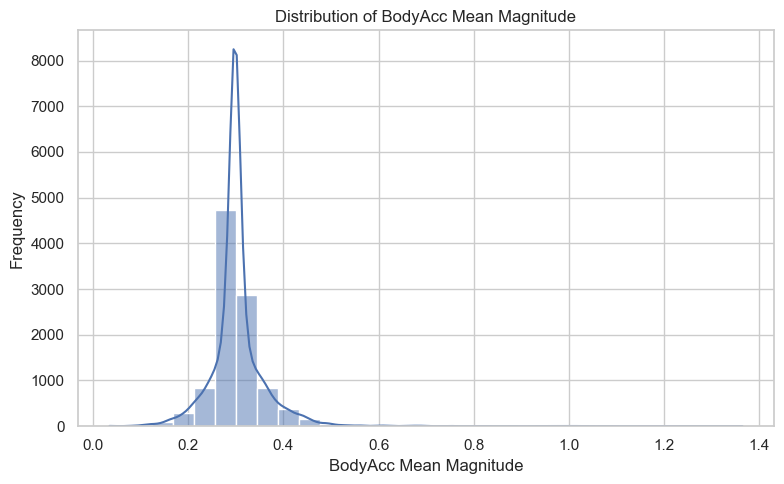

In [22]:
plt.figure(figsize=(8, 5))

sns.histplot(
    X["BodyAcc_Mean_Magnitude"],
    bins=30,
    kde=True
)

plt.title("Distribution of BodyAcc Mean Magnitude")
plt.xlabel("BodyAcc Mean Magnitude")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Observation

The engineered feature shows the distribution of the overall magnitude of mean body acceleration. Combining the three directional components provides a direction-independent representation of body acceleration.

# 17. Train-Test Split

The complete dataset is divided into training and testing sets.

80% of the data is used for training and 20% is used for testing. Stratification is applied so that the activity class distribution is maintained in both sets.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Outlier Treatment

Outlier limits are calculated using the training data only. Extreme feature values are capped using the training-derived IQR limits and the same limits are applied to the test data to avoid data leakage.

In [24]:
# Calculate outlier limits using training data only
Q1_train = X_train.quantile(0.25)
Q3_train = X_train.quantile(0.75)

IQR_train = Q3_train - Q1_train

lower_train = Q1_train - 1.5 * IQR_train
upper_train = Q3_train + 1.5 * IQR_train

# Cap extreme values using training-derived limits
X_train = X_train.clip(
    lower=lower_train,
    upper=upper_train,
    axis=1
)

X_test = X_test.clip(
    lower=lower_train,
    upper=upper_train,
    axis=1
)

# 18. Feature Scaling

StandardScaler is used to standardise the feature values.

The scaler is fitted only on the training data and then applied to both training and testing data. This prevents information from the test set from influencing the scaling process.

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training data scaled:", X_train_scaled.shape)
print("Testing data scaled:", X_test_scaled.shape)

Training data scaled: (8239, 562)
Testing data scaled: (2060, 562)


# 19. Logistic Regression

Logistic Regression is used as one of the classification algorithms for predicting the six human activity classes.

The model is trained using the scaled training data. Both predicted classes and class probabilities are generated for later evaluation.

In [26]:
#LOGISTIC REGRESSION
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test_scaled
)

logistic_prob = logistic_model.predict_proba(
    X_test_scaled
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


# 20. K-Nearest Neighbours

K-Nearest Neighbours classifies an observation based on the classes of its nearest neighbouring observations.

The model uses five neighbours and is trained using the scaled feature data.

In [27]:
#KNN
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_pred = knn_model.predict(
    X_test_scaled
)

knn_prob = knn_model.predict_proba(
    X_test_scaled
)

print("KNN trained successfully.")

KNN trained successfully.


# 21. Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classification algorithm.

It is trained on the scaled features and produces both predicted activity classes and class probabilities for evaluation.

In [28]:
#GAUSSIAN NAIVE BAYES
nb_model = GaussianNB()

nb_model.fit(
    X_train_scaled,
    y_train
)

nb_pred = nb_model.predict(
    X_test_scaled
)

nb_prob = nb_model.predict_proba(
    X_test_scaled
)

print("Gaussian Naive Bayes trained successfully.")

Gaussian Naive Bayes trained successfully.


# 22. Decision Tree

A Decision Tree classifier learns decision rules from the input features to classify the different human activities.

The model is trained using the original unscaled feature values.

In [29]:
#DECISION TREE
dt_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_pred = dt_model.predict(
    X_test
)

dt_prob = dt_model.predict_proba(
    X_test
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


# 23. Support Vector Machine

Support Vector Machine is implemented using an RBF kernel.

The model is trained using the scaled feature data. Probability estimation is enabled to calculate probability-based evaluation metrics such as ROC-AUC.

In [30]:
#SVM
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

svm_pred = svm_model.predict(
    X_test_scaled
)

svm_prob = svm_model.predict_proba(
    X_test_scaled
)

print("SVM trained successfully.")

SVM trained successfully.


# 24. Classification Evaluation Metrics

A common evaluation function is created to evaluate all classification models using the same performance measures.

The evaluation metrics include Accuracy, Precision, Recall, Weighted F1-score and ROC-AUC.

In [31]:
def evaluate_classification_model(
    name,
    y_true,
    y_pred,
    y_prob
):
    
    accuracy = accuracy_score(
        y_true,
        y_pred
    )
    
    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )
    
    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )
    
    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )
    
    roc_auc = roc_auc_score(
        y_true,
        y_prob,
        multi_class="ovr"
    )
    
    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Weighted F1": f1,
        "ROC-AUC": roc_auc
    }

# 25. Model Comparison

The predictions generated by all five classification algorithms are evaluated using the common evaluation function.

The results are stored in a DataFrame and sorted according to Accuracy to make model comparison easier.

In [33]:
classification_results = []

classification_results.append(
    evaluate_classification_model(
        "Logistic Regression",
        y_test,
        logistic_pred,
        logistic_prob
    )
)

classification_results.append(
    evaluate_classification_model(
        "KNN",
        y_test,
        knn_pred,
        knn_prob
    )
)

classification_results.append(
    evaluate_classification_model(
        "Gaussian Naive Bayes",
        y_test,
        nb_pred,
        nb_prob
    )
)

classification_results.append(
    evaluate_classification_model(
        "Decision Tree",
        y_test,
        dt_pred,
        dt_prob
    )
)

classification_results.append(
    evaluate_classification_model(
        "SVM",
        y_test,
        svm_pred,
        svm_prob
    )
)

classification_results_df = pd.DataFrame(
    classification_results
)

classification_results_df = (
    classification_results_df
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

classification_results_df

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Logistic Regression,0.984951,0.985004,0.984951,0.984954,0.999571
1,SVM,0.978641,0.978798,0.978641,0.978651,0.999302
2,KNN,0.962621,0.962746,0.962621,0.962597,0.996105
3,Decision Tree,0.936408,0.936781,0.936408,0.936490,0.961029
4,Gaussian Naive Bayes,0.755340,0.785837,0.755340,0.748388,0.962438


# 26. Formatted Comparison Results

The evaluation results are formatted to four decimal places.

This improves the readability of the model comparison table.

In [71]:
classification_results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "Weighted F1": "{:.4f}",
    "ROC-AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Logistic Regression,0.9850,0.9850,0.9850,0.9850,0.9996
1,SVM,0.9786,0.9788,0.9786,0.9787,0.9993
2,KNN,0.9626,0.9627,0.9626,0.9626,0.9961
3,Decision Tree,0.9364,0.9368,0.9364,0.9365,0.9610
4,Gaussian Naive Bayes,0.7553,0.7858,0.7553,0.7484,0.9624


# 27. Accuracy Comparison

A bar plot is used to visually compare the accuracy of the five classification models.

This provides a simple graphical representation of the differences in classification performance.

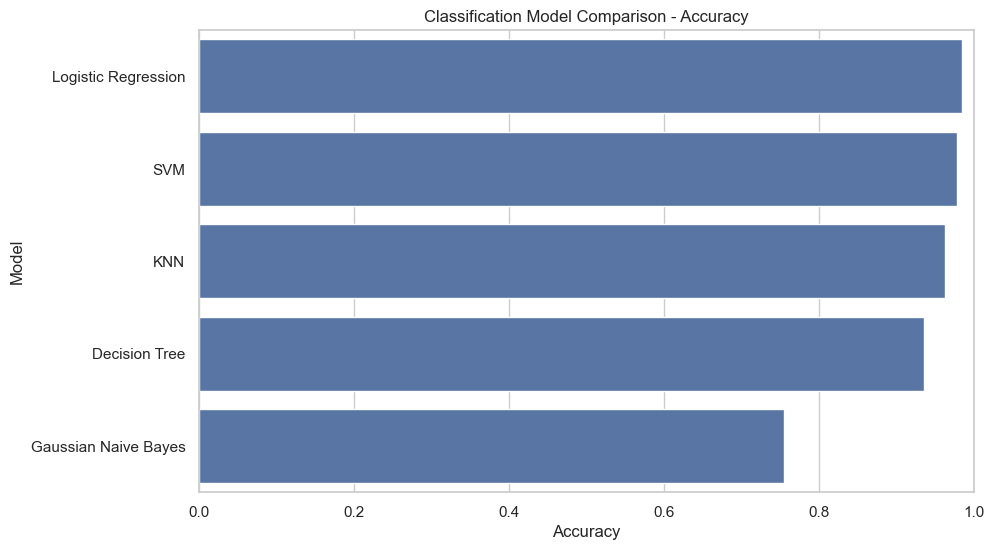

In [72]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=classification_results_df,
    x="Accuracy",
    y="Model"
)

plt.title("Classification Model Comparison - Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.show()

# 28. Confusion Matrix Analysis

A confusion matrix is generated for each classification model.

It shows the relationship between the actual activity classes and the predicted activity classes, helping to identify correct classifications and misclassifications.

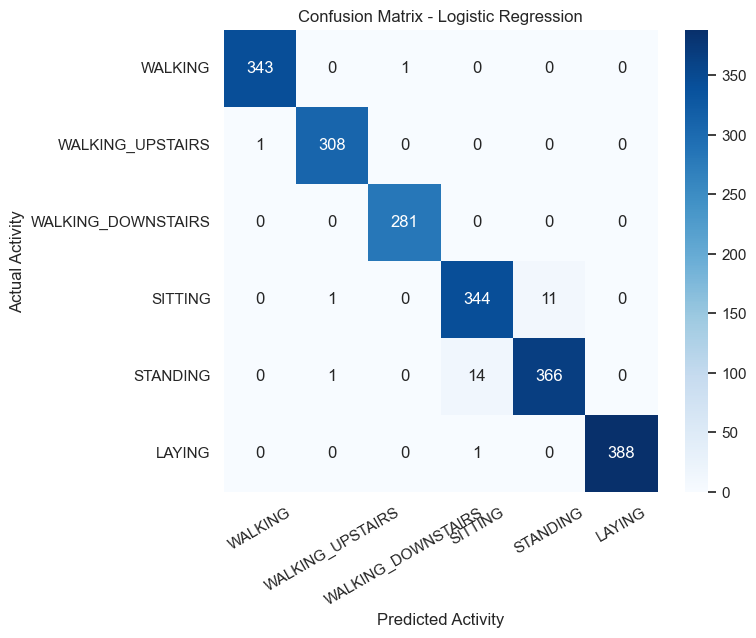

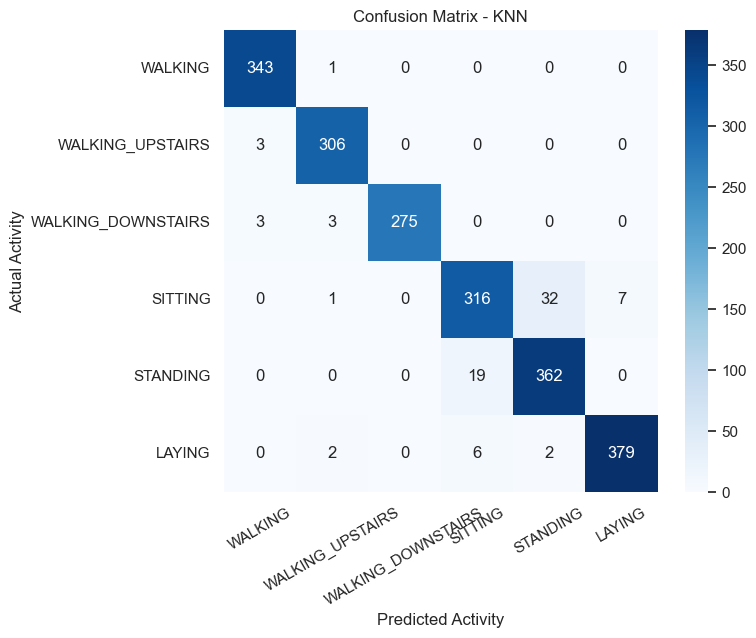

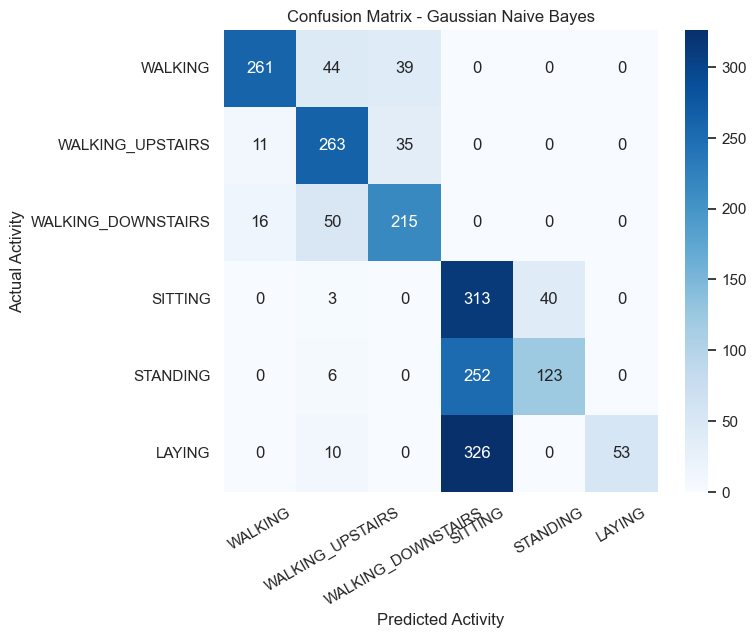

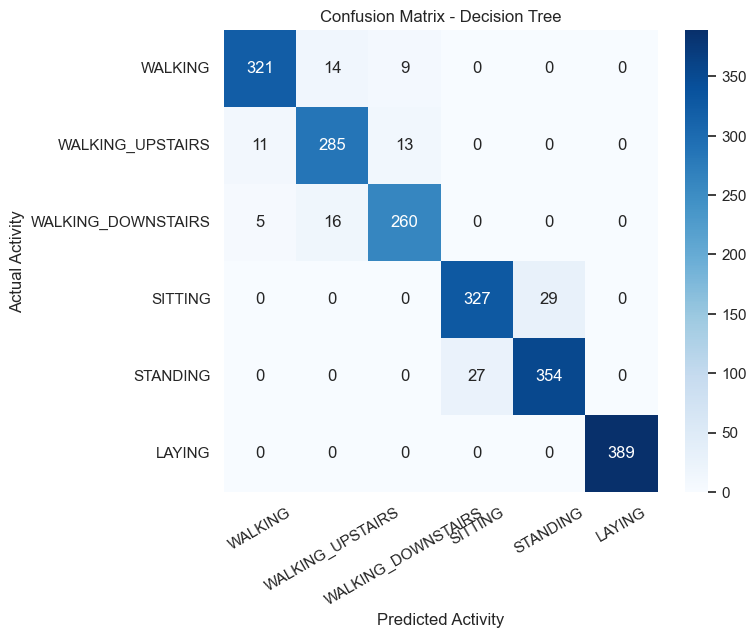

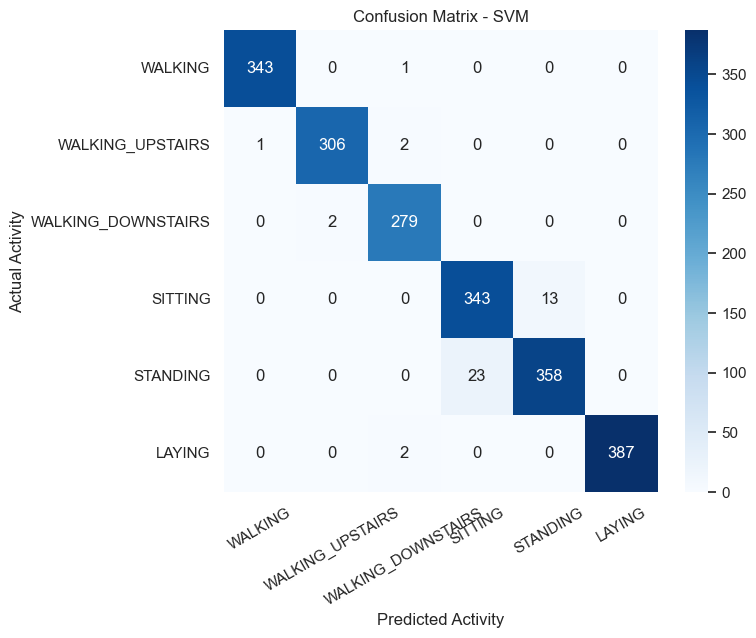

In [73]:
predictions = {
    "Logistic Regression": logistic_pred,
    "KNN": knn_pred,
    "Gaussian Naive Bayes": nb_pred,
    "Decision Tree": dt_pred,
    "SVM": svm_pred
}

for name, predictions_model in predictions.items():
    
    cm = confusion_matrix(
        y_test,
        predictions_model
    )
    
    plt.figure(figsize=(7, 6))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=activity_labels["activity"],
        yticklabels=activity_labels["activity"]
    )
    
    plt.title(
        f"Confusion Matrix - {name}"
    )
    
    plt.xlabel("Predicted Activity")
    plt.ylabel("Actual Activity")
    plt.xticks(rotation=30)
    plt.yticks(rotation=0)
    
    plt.show()

# 29. Decision Tree Visualization

The Decision Tree model is visualised to show its learned decision structure.

Only the first three levels are displayed so that the tree can be interpreted more easily.

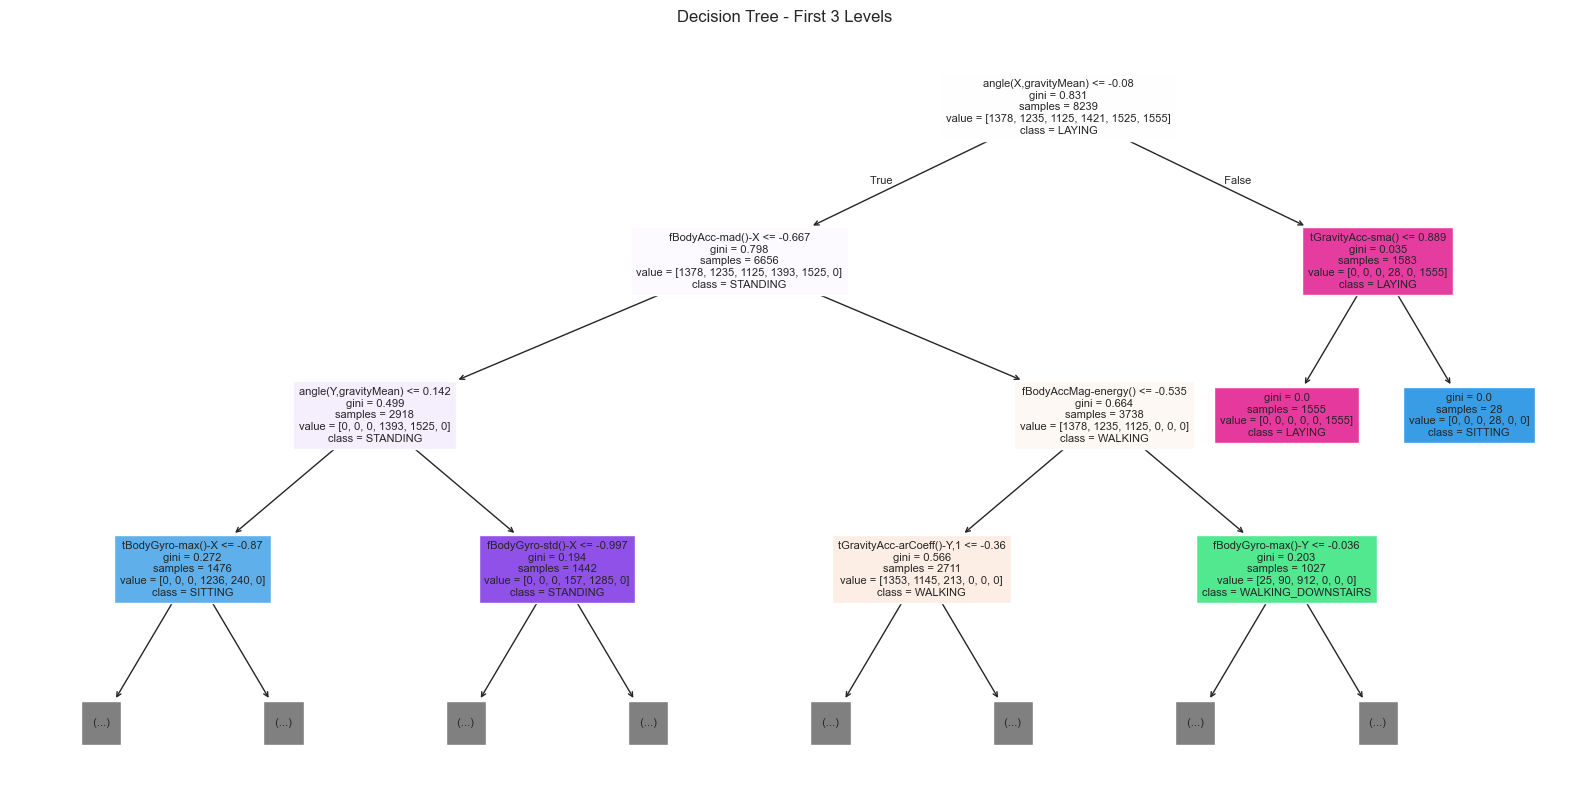

In [74]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    max_depth=3,
    filled=True,
    feature_names=X_train.columns.tolist(),
    class_names=activity_labels["activity"].tolist(),
    fontsize=8
)

plt.title("Decision Tree - First 3 Levels")
plt.show()

# 30. Classification Report for the Selected Model

The model appearing first in the accuracy-sorted results table is selected for detailed evaluation.

A classification report is generated to show precision, recall, F1-score and support for each activity class.

In [75]:
best_model_name = classification_results_df.iloc[0]["Model"]

best_predictions = predictions[best_model_name]

print("Best model:", best_model_name)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=activity_labels["activity"]
    )
)

Best model: Logistic Regression

Classification Report:
                    precision    recall  f1-score   support

           WALKING       1.00      1.00      1.00       344
  WALKING_UPSTAIRS       0.99      1.00      1.00       309
WALKING_DOWNSTAIRS       1.00      1.00      1.00       281
           SITTING       0.96      0.97      0.96       356
          STANDING       0.97      0.96      0.97       381
            LAYING       1.00      1.00      1.00       389

          accuracy                           0.99      2060
         macro avg       0.99      0.99      0.99      2060
      weighted avg       0.99      0.99      0.99      2060



## Classification Part A Conclusion
Five classification algorithms were evaluated on the Human Activity Recognition dataset: Logistic Regression, KNN, Gaussian Naive Bayes, Decision Tree and SVM.

The models were evaluated using Accuracy, Precision, Recall, weighted F1-score and ROC-AUC. Confusion matrices were also examined to understand the classification performance across the six activity classes.

The model with the strongest overall performance was selected based on the comparison of the evaluation metrics. The results show how different classification algorithms perform on smartphone sensor-based human activity recognition.